In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_FILE = Path(
    "../data/processed/detection_dos_cleaned.csv"
)

df = pd.read_csv(DATA_FILE)

print("Dataset loaded")
print("Shape:", df.shape)
print("Columns:", len(df.columns))

Dataset loaded
Shape: (1048575, 69)
Columns: 69


In [2]:
# ============================================================
# ROBUST BEHAVIOURAL FEATURE ENGINEERING
# ============================================================

df_feat = df.copy()

# Small helper for safe division.
def safe_divide(numerator, denominator):
    return np.divide(
        numerator,
        denominator,
        out=np.zeros_like(
            numerator,
            dtype=float
        ),
        where=denominator != 0
    )


# ------------------------------------------------------------
# 1. Directional packet share
# Bounded between 0 and 1.
# ------------------------------------------------------------

total_pkts = (
    df_feat["Tot Fwd Pkts"] +
    df_feat["Tot Bwd Pkts"]
)

df_feat["Fwd_Pkt_Share"] = safe_divide(
    df_feat["Tot Fwd Pkts"].to_numpy(),
    total_pkts.to_numpy()
)

df_feat["Bwd_Pkt_Share"] = safe_divide(
    df_feat["Tot Bwd Pkts"].to_numpy(),
    total_pkts.to_numpy()
)


# ------------------------------------------------------------
# 2. Directional byte share
# Bounded between 0 and 1.
# ------------------------------------------------------------

total_bytes = (
    df_feat["TotLen Fwd Pkts"] +
    df_feat["TotLen Bwd Pkts"]
)

df_feat["Fwd_Byte_Share"] = safe_divide(
    df_feat["TotLen Fwd Pkts"].to_numpy(),
    total_bytes.to_numpy()
)

df_feat["Bwd_Byte_Share"] = safe_divide(
    df_feat["TotLen Bwd Pkts"].to_numpy(),
    total_bytes.to_numpy()
)


# ------------------------------------------------------------
# 3. Bytes per packet
# ------------------------------------------------------------

df_feat["Fwd_Bytes_per_Pkt"] = safe_divide(
    df_feat["TotLen Fwd Pkts"].to_numpy(),
    df_feat["Tot Fwd Pkts"].to_numpy()
)

df_feat["Bwd_Bytes_per_Pkt"] = safe_divide(
    df_feat["TotLen Bwd Pkts"].to_numpy(),
    df_feat["Tot Bwd Pkts"].to_numpy()
)


# ------------------------------------------------------------
# 4. Packet-rate features
# ------------------------------------------------------------

df_feat["Total_Pkts_per_s"] = (
    df_feat["Flow Pkts/s"]
)

df_feat["Total_Bytes_per_s"] = (
    df_feat["Flow Byts/s"]
)


# ------------------------------------------------------------
# 5. TCP flag ratios
# ------------------------------------------------------------

df_feat["SYN_per_Pkt"] = safe_divide(
    df_feat["SYN Flag Cnt"].to_numpy(),
    total_pkts.to_numpy()
)

df_feat["ACK_per_Pkt"] = safe_divide(
    df_feat["ACK Flag Cnt"].to_numpy(),
    total_pkts.to_numpy()
)

df_feat["RST_per_Pkt"] = safe_divide(
    df_feat["RST Flag Cnt"].to_numpy(),
    total_pkts.to_numpy()
)


# ------------------------------------------------------------
# 6. Packet-size asymmetry
# ------------------------------------------------------------

df_feat["Fwd_Bwd_PktLen_Ratio"] = safe_divide(
    df_feat["Fwd Pkt Len Mean"].to_numpy(),
    df_feat["Bwd Pkt Len Mean"].to_numpy()
)

# Log-transform highly skewed behavioural quantities.
df_feat["Log_Flow_Duration"] = np.log1p(
    df_feat["Flow Duration"].clip(lower=0)
)

df_feat["Log_Flow_Pkts_s"] = np.log1p(
    df_feat["Flow Pkts/s"].clip(lower=0)
)

df_feat["Log_Flow_Bytes_s"] = np.log1p(
    df_feat["Flow Byts/s"].clip(lower=0)
)


new_features = [
    "Fwd_Pkt_Share",
    "Bwd_Pkt_Share",
    "Fwd_Byte_Share",
    "Bwd_Byte_Share",
    "Fwd_Bytes_per_Pkt",
    "Bwd_Bytes_per_Pkt",
    "Total_Pkts_per_s",
    "Total_Bytes_per_s",
    "SYN_per_Pkt",
    "ACK_per_Pkt",
    "RST_per_Pkt",
    "Fwd_Bwd_PktLen_Ratio",
    "Log_Flow_Duration",
    "Log_Flow_Pkts_s",
    "Log_Flow_Bytes_s"
]

print("✅ Robust behavioural features created")
print("New features:", len(new_features))

display(
    df_feat[new_features].head()
)

✅ Robust behavioural features created
New features: 15


,Fwd_Pkt_Share,Bwd_Pkt_Share,Fwd_Byte_Share,Bwd_Byte_Share,Fwd_Bytes_per_Pkt,Bwd_Bytes_per_Pkt,Total_Pkts_per_s,Total_Bytes_per_s,SYN_per_Pkt,ACK_per_Pkt,RST_per_Pkt,Fwd_Bwd_PktLen_Ratio,Log_Flow_Duration,Log_Flow_Pkts_s,Log_Flow_Bytes_s
0,0.625,0.375,0.515267,0.484733,27.0,42.333333,210.787026,6903.275103,0.0,0.0,0.0,0.637795,10.544130,5.355581,8.839896
1,1.000,0.000,1.000000,0.000000,500.0,0.000000,0.025516,12.757980,0.0,0.0,0.0,0.000000,18.582574,0.025196,2.621619
2,1.000,0.000,1.000000,0.000000,500.0,0.000000,0.025516,12.757980,0.0,0.0,0.0,0.000000,18.582574,0.025196,2.621619
3,1.000,0.000,1.000000,0.000000,500.0,0.000000,0.050128,25.064165,0.0,0.0,0.0,0.000000,18.418117,0.048912,3.260561
4,1.000,0.000,1.000000,0.000000,500.0,0.000000,0.050128,25.064165,0.0,0.0,0.0,0.000000,18.418117,0.048912,3.260561


In [3]:
feature_check = df_feat[new_features]

print("Missing values:")
print(feature_check.isna().sum().sum())

print("\nInfinite values:")
print(
    np.isinf(
        feature_check.to_numpy()
    ).sum()
)

print("\nMaximum values:")
display(
    feature_check.max().sort_values(ascending=False).head(10)
)

Missing values:
0

Infinite values:
0

Maximum values:


Total_Bytes_per_s       2.077430e+06
Total_Pkts_per_s        1.000000e+06
Bwd_Bytes_per_Pkt       1.104000e+03
Fwd_Bytes_per_Pkt       9.760000e+02
Fwd_Bwd_PktLen_Ratio    6.102000e+01
Log_Flow_Duration       1.860300e+01
Log_Flow_Bytes_s        1.454664e+01
Log_Flow_Pkts_s         1.381551e+01
Fwd_Pkt_Share           1.000000e+00
Fwd_Byte_Share          1.000000e+00
dtype: float64

In [4]:
display(
    df_feat[new_features]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
Fwd_Pkt_Share,1048575.0,0.812930,0.209711,0.142857,0.714286,1.000000,1.000000,1.000000e+00
Bwd_Pkt_Share,1048575.0,0.187070,0.209711,0.000000,0.000000,0.000000,0.285714,8.571429e-01
Fwd_Byte_Share,1048575.0,0.300349,0.344782,0.000000,0.000000,0.208968,0.747402,1.000000e+00
Bwd_Byte_Share,1048575.0,0.201326,0.263683,0.000000,0.000000,0.000000,0.252598,1.000000e+00
Fwd_Bytes_per_Pkt,1048575.0,79.771443,85.111390,0.000000,0.000000,32.000000,187.000000,9.760000e+02
Bwd_Bytes_per_Pkt,1048575.0,87.771447,92.673012,0.000000,0.000000,0.000000,158.000000,1.104000e+03
Total_Pkts_per_s,1048575.0,1877.982163,4528.751514,0.022352,302.010527,758.725341,3129.890454,1.000000e+06
Total_Bytes_per_s,1048575.0,259916.047508,398486.324463,0.000000,0.000000,33.527132,405294.341500,2.077430e+06
SYN_per_Pkt,1048575.0,0.000004,0.001223,0.000000,0.000000,0.000000,0.000000,5.000000e-01
ACK_per_Pkt,1048575.0,0.249056,0.249995,0.000000,0.000000,0.000000,0.500000,5.000000e-01


In [5]:
# ============================================================
# LOAD RAW LABELS FOR FEATURE ANALYSIS
# ============================================================

RAW_FILE = "../data/raw/Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv"

raw_analysis = pd.read_csv(RAW_FILE)

raw_analysis["Timestamp"] = pd.to_datetime(
    raw_analysis["Timestamp"],
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

raw_analysis = raw_analysis.drop_duplicates().reset_index(drop=True)

print("Raw analysis shape:", raw_analysis.shape)
print("\nLabels:")
print(raw_analysis["Label"].value_counts())

Raw analysis shape: (1031018, 80)

Labels:
Label
DDOS attack-HOIC        668461
Benign                  360827
DDOS attack-LOIC-UDP      1730
Name: count, dtype: int64


In [6]:
# ============================================================
# CREATE ROBUST BEHAVIOURAL FEATURES ON RAW DATA
# Keeps Label + Timestamp for analysis
# ============================================================

analysis = raw_analysis.copy()


def safe_divide(numerator, denominator):
    return np.divide(
        numerator,
        denominator,
        out=np.zeros_like(
            numerator,
            dtype=float
        ),
        where=denominator != 0
    )


# ------------------------------------------------------------
# Packet direction
# ------------------------------------------------------------

total_pkts = (
    analysis["Tot Fwd Pkts"] +
    analysis["Tot Bwd Pkts"]
)

analysis["Fwd_Pkt_Share"] = safe_divide(
    analysis["Tot Fwd Pkts"].to_numpy(),
    total_pkts.to_numpy()
)

analysis["Bwd_Pkt_Share"] = safe_divide(
    analysis["Tot Bwd Pkts"].to_numpy(),
    total_pkts.to_numpy()
)


# ------------------------------------------------------------
# Byte direction
# ------------------------------------------------------------

total_bytes = (
    analysis["TotLen Fwd Pkts"] +
    analysis["TotLen Bwd Pkts"]
)

analysis["Fwd_Byte_Share"] = safe_divide(
    analysis["TotLen Fwd Pkts"].to_numpy(),
    total_bytes.to_numpy()
)

analysis["Bwd_Byte_Share"] = safe_divide(
    analysis["TotLen Bwd Pkts"].to_numpy(),
    total_bytes.to_numpy()
)


# ------------------------------------------------------------
# Bytes per packet
# ------------------------------------------------------------

analysis["Fwd_Bytes_per_Pkt"] = safe_divide(
    analysis["TotLen Fwd Pkts"].to_numpy(),
    analysis["Tot Fwd Pkts"].to_numpy()
)

analysis["Bwd_Bytes_per_Pkt"] = safe_divide(
    analysis["TotLen Bwd Pkts"].to_numpy(),
    analysis["Tot Bwd Pkts"].to_numpy()
)


# ------------------------------------------------------------
# Packet + byte rates
# ------------------------------------------------------------

analysis["Total_Pkts_per_s"] = analysis["Flow Pkts/s"]

analysis["Total_Bytes_per_s"] = analysis["Flow Byts/s"]


# ------------------------------------------------------------
# TCP flag ratios
# ------------------------------------------------------------

analysis["SYN_per_Pkt"] = safe_divide(
    analysis["SYN Flag Cnt"].to_numpy(),
    total_pkts.to_numpy()
)

analysis["ACK_per_Pkt"] = safe_divide(
    analysis["ACK Flag Cnt"].to_numpy(),
    total_pkts.to_numpy()
)

analysis["RST_per_Pkt"] = safe_divide(
    analysis["RST Flag Cnt"].to_numpy(),
    total_pkts.to_numpy()
)


# ------------------------------------------------------------
# Packet-size asymmetry
# ------------------------------------------------------------

analysis["Fwd_Bwd_PktLen_Ratio"] = safe_divide(
    analysis["Fwd Pkt Len Mean"].to_numpy(),
    analysis["Bwd Pkt Len Mean"].to_numpy()
)


# ------------------------------------------------------------
# Log transforms for highly skewed features
# ------------------------------------------------------------

analysis["Log_Flow_Duration"] = np.log1p(
    analysis["Flow Duration"].clip(lower=0)
)

analysis["Log_Flow_Pkts_s"] = np.log1p(
    analysis["Flow Pkts/s"].clip(lower=0)
)

analysis["Log_Flow_Bytes_s"] = np.log1p(
    analysis["Flow Byts/s"].clip(lower=0)
)


new_features = [
    "Fwd_Pkt_Share",
    "Bwd_Pkt_Share",
    "Fwd_Byte_Share",
    "Bwd_Byte_Share",
    "Fwd_Bytes_per_Pkt",
    "Bwd_Bytes_per_Pkt",
    "Total_Pkts_per_s",
    "Total_Bytes_per_s",
    "SYN_per_Pkt",
    "ACK_per_Pkt",
    "RST_per_Pkt",
    "Fwd_Bwd_PktLen_Ratio",
    "Log_Flow_Duration",
    "Log_Flow_Pkts_s",
    "Log_Flow_Bytes_s"
]

print("Behavioural features added to raw analysis")
print("Rows:", len(analysis))
print("New features:", len(new_features))

Behavioural features added to raw analysis
Rows: 1031018
New features: 15


In [7]:
# ============================================================
# HOIC vs LOIC: BEHAVIOURAL COMPARISON
# ============================================================

attack_analysis = analysis[
    analysis["Label"].isin([
        "DDOS attack-HOIC",
        "DDOS attack-LOIC-UDP"
    ])
].copy()

behavior_comparison = (
    attack_analysis
    .groupby("Label")[new_features]
    .median()
    .T
)

display(behavior_comparison)

Label,DDOS attack-HOIC,DDOS attack-LOIC-UDP
Fwd_Pkt_Share,1.000000,1.000000
Bwd_Pkt_Share,0.000000,0.000000
Fwd_Byte_Share,0.000000,1.000000
Bwd_Byte_Share,0.000000,0.000000
Fwd_Bytes_per_Pkt,0.000000,32.000000
Bwd_Bytes_per_Pkt,0.000000,0.000000
Total_Pkts_per_s,474.962681,1016.364598
Total_Bytes_per_s,0.000000,32523.667130
SYN_per_Pkt,0.000000,0.000000
ACK_per_Pkt,0.500000,0.000000


In [8]:
# ============================================================
# RELATIVE DIFFERENCE BETWEEN HOIC AND LOIC
# ============================================================

hoic_values = behavior_comparison["DDOS attack-HOIC"]
loic_values = behavior_comparison["DDOS attack-LOIC-UDP"]

comparison = pd.DataFrame({
    "HOIC_median": hoic_values,
    "LOIC_median": loic_values
})

comparison["Absolute_difference"] = (
    comparison["LOIC_median"] -
    comparison["HOIC_median"]
).abs()

comparison = comparison.sort_values(
    "Absolute_difference",
    ascending=False
)

display(comparison)

,HOIC_median,LOIC_median,Absolute_difference
Total_Bytes_per_s,0.000000,32523.667130,32523.667130
Total_Pkts_per_s,474.962681,1016.364598,541.401916
Fwd_Bytes_per_Pkt,0.000000,32.000000,32.000000
Log_Flow_Bytes_s,0.000000,10.389754,10.389754
Log_Flow_Duration,8.814925,18.601145,9.786220
Fwd_Byte_Share,0.000000,1.000000,1.000000
Log_Flow_Pkts_s,6.165339,6.924971,0.759631
ACK_per_Pkt,0.500000,0.000000,0.500000
Fwd_Pkt_Share,1.000000,1.000000,0.000000
Bwd_Pkt_Share,0.000000,0.000000,0.000000


In [9]:
behavior_plot_features = [
    "Total_Pkts_per_s",
    "Total_Bytes_per_s",
    "Fwd_Pkt_Share",
    "Bwd_Pkt_Share",
    "SYN_per_Pkt",
    "ACK_per_Pkt",
    "Log_Flow_Duration"
]

In [10]:
import matplotlib.pyplot as plt

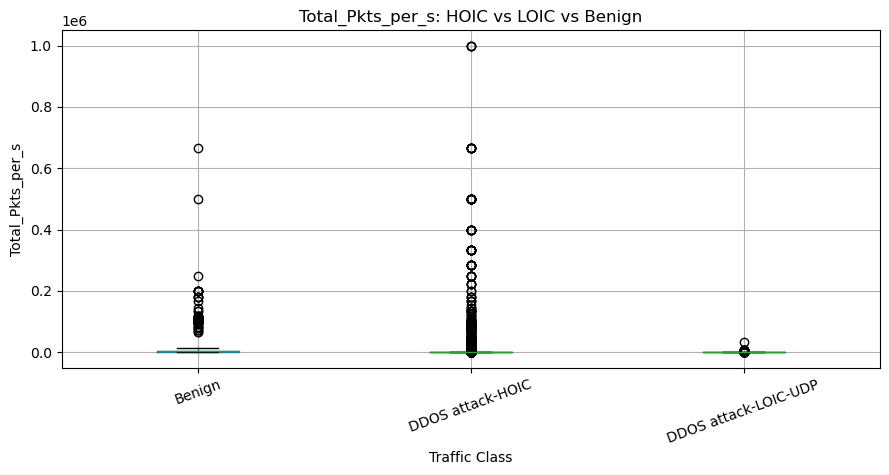

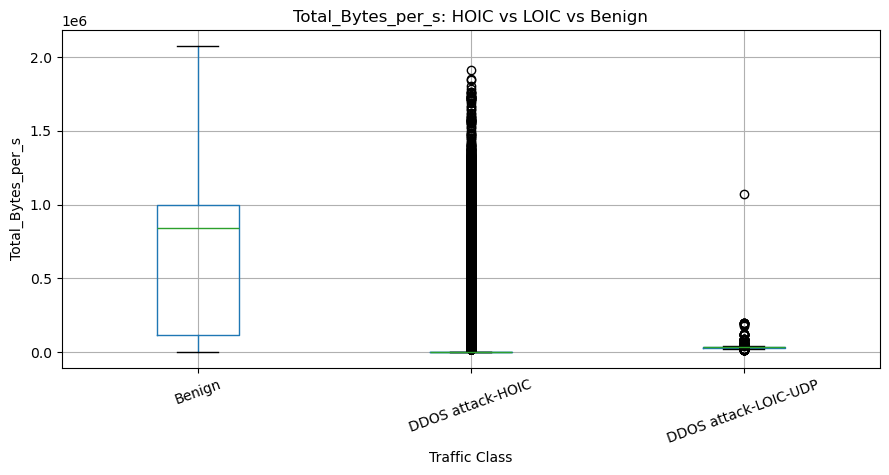

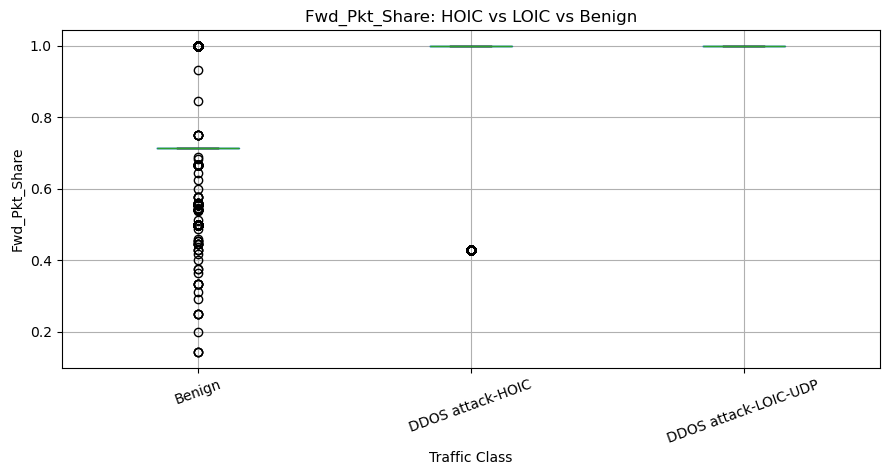

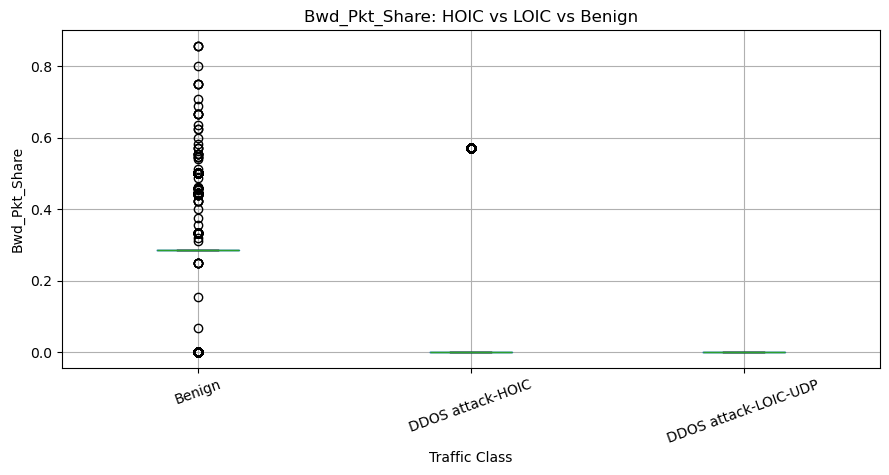

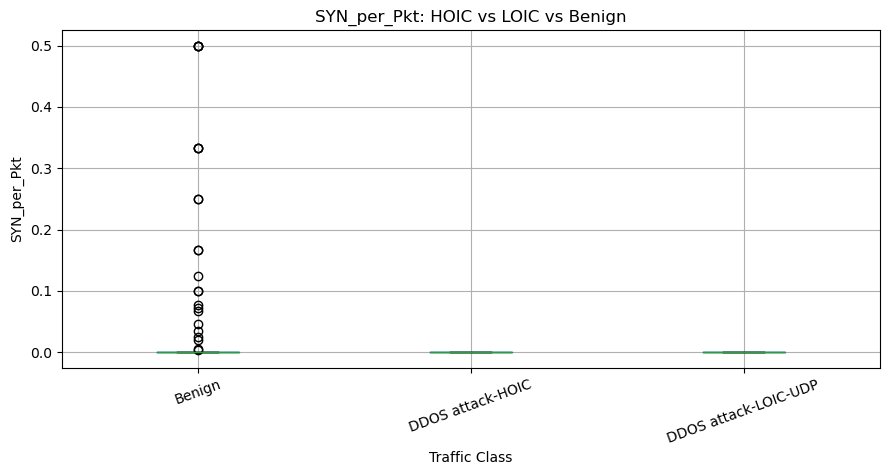

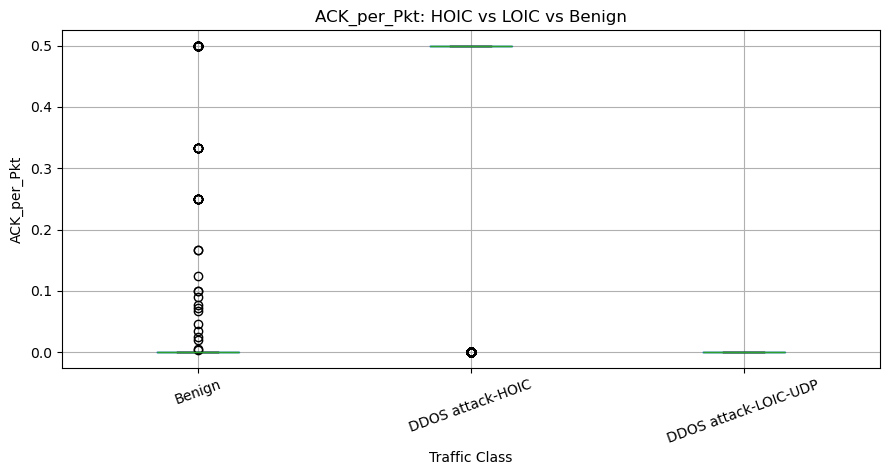

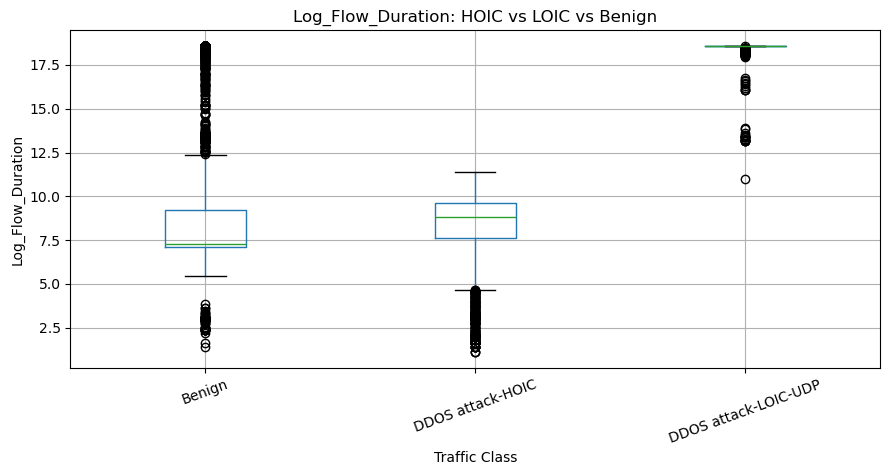

In [11]:
for feature in behavior_plot_features:

    analysis.boxplot(
        column=feature,
        by="Label",
        figsize=(9, 5)
    )

    plt.title(f"{feature}: HOIC vs LOIC vs Benign")
    plt.suptitle("")
    plt.xlabel("Traffic Class")
    plt.ylabel(feature)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

In [12]:
# ============================================================
# TEMPORAL WINDOW FEATURES
# Convert individual flows into short streaming windows.
# ============================================================

window_df = analysis.copy()

# Binary target
window_df["Target"] = (
    ~window_df["Label"]
    .str.strip()
    .str.lower()
    .eq("benign")
).astype(int)

# Put every flow into a 10-second window
window_df["time_window"] = (
    window_df["Timestamp"]
    .dt.floor("10s")
)

print("Number of flows:", len(window_df))
print("Number of 10-second windows:",
      window_df["time_window"].nunique())

Number of flows: 1031018
Number of 10-second windows: 637


In [13]:
# ============================================================
# AGGREGATE TRAFFIC BEHAVIOUR PER 10-SECOND WINDOW
# ============================================================

temporal_features = (
    window_df
    .groupby("time_window")
    .agg(
        flow_count=("Label", "size"),

        total_packets=("Tot Fwd Pkts", "sum"),
        total_bytes=("TotLen Fwd Pkts", "sum"),

        mean_flow_duration=("Flow Duration", "mean"),
        median_flow_duration=("Flow Duration", "median"),

        mean_packets_per_second=("Flow Pkts/s", "mean"),
        max_packets_per_second=("Flow Pkts/s", "max"),

        mean_bytes_per_second=("Flow Byts/s", "mean"),
        max_bytes_per_second=("Flow Byts/s", "max"),

        mean_pkt_size=("Pkt Size Avg", "mean"),

        mean_iat=("Flow IAT Mean", "mean"),
        mean_syn_count=("SYN Flag Cnt", "mean"),
        mean_ack_count=("ACK Flag Cnt", "mean"),

        attack_ratio=("Target", "mean")
    )
    .reset_index()
)

print("Temporal feature table created")
print("Shape:", temporal_features.shape)

display(temporal_features.head(10))

Temporal feature table created
Shape: (637, 15)


,time_window,flow_count,total_packets,total_bytes,mean_flow_duration,median_flow_duration,mean_packets_per_second,max_packets_per_second,mean_bytes_per_second,max_bytes_per_second,mean_pkt_size,mean_iat,mean_syn_count,mean_ack_count,attack_ratio
0,2018-02-21 01:55:40,3,10,3384,7.890551e+07,117573216.0,1.715434,5.095269,103.617022,2.853351e+02,465.777778,3.927477e+07,0.333333,0.333333,0.0
1,2018-02-21 01:56:10,4,22,7037,6.013818e+07,75507833.5,39.361686,157.133878,4547.305209,1.810531e+04,344.040404,1.049019e+07,0.000000,0.250000,0.0
2,2018-02-21 01:56:20,1,5,20,7.723100e+05,772310.0,11.653352,11.653352,1342.725072,1.342725e+03,115.222222,9.653875e+04,0.000000,0.000000,0.0
3,2018-02-21 01:56:30,1,3,0,1.126414e+08,112641350.0,0.026633,0.026633,0.000000,0.000000e+00,0.000000,5.630000e+07,0.000000,0.000000,0.0
4,2018-02-21 01:56:50,2,12,6000,8.947964e+07,89479642.5,0.067054,0.067054,33.527179,3.352718e+01,583.333333,1.790000e+07,0.000000,0.000000,0.0
5,2018-02-21 01:57:30,1,5,20,6.929550e+05,692955.0,12.987856,12.987856,1496.489671,1.496490e+03,115.222222,8.661938e+04,0.000000,0.000000,0.0
6,2018-02-21 01:57:40,2,10,5000,8.547921e+07,85479209.5,0.058494,0.058494,29.246878,2.924688e+01,600.000000,2.140000e+07,0.000000,0.000000,0.0
7,2018-02-21 01:58:10,1,5,20,7.916400e+04,79164.0,113.688040,113.688040,13099.388610,1.309939e+04,115.222222,9.895500e+03,0.000000,0.000000,0.0
8,2018-02-21 01:58:30,2,6,639,1.356495e+05,135649.5,40557.129668,81081.081080,759705.935285,1.513514e+06,107.555556,1.696312e+04,0.500000,0.500000,0.0
9,2018-02-21 01:58:40,1,5,20,6.771090e+05,677109.0,13.291804,13.291804,1531.511175,1.531511e+03,115.222222,8.463862e+04,0.000000,0.000000,0.0


In [14]:
temporal_features["Window_Target"] = (
    temporal_features["attack_ratio"] > 0
).astype(int)

print(
    temporal_features["Window_Target"]
    .value_counts()
)

print("\nWindow attack ratio:")
display(
    temporal_features["attack_ratio"].describe()
)

Window_Target
0    362
1    275
Name: count, dtype: int64

Window attack ratio:


count    637.000000
mean       0.269337
std        0.343019
min        0.000000
25%        0.000000
50%        0.000000
75%        0.494741
max        1.000000
Name: attack_ratio, dtype: float64

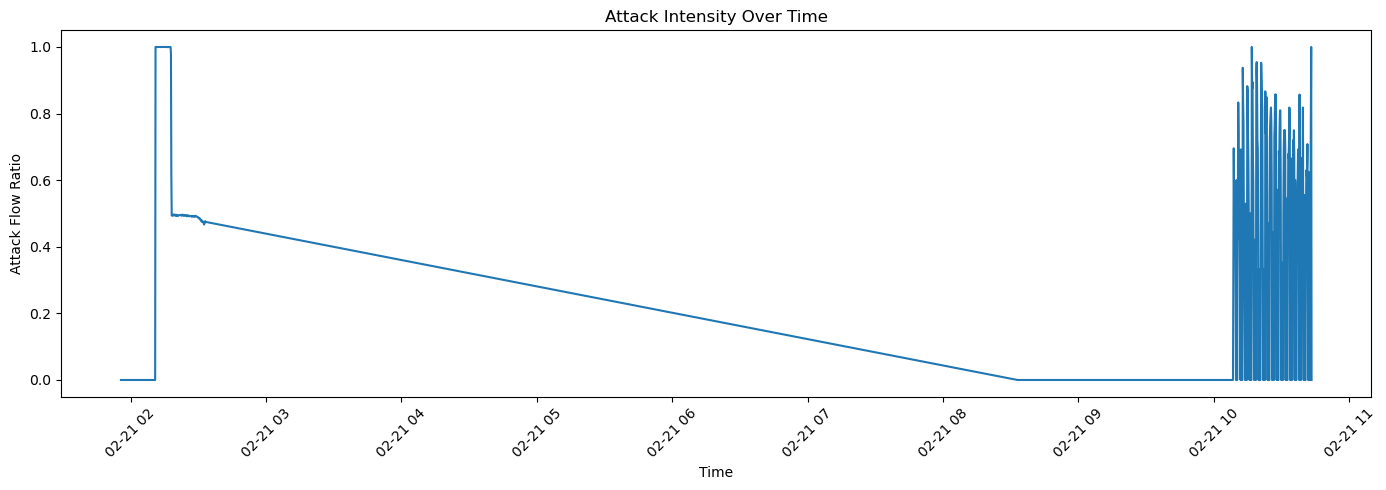

In [15]:
plt.figure(figsize=(14, 5))

plt.plot(
    temporal_features["time_window"],
    temporal_features["attack_ratio"]
)

plt.title("Attack Intensity Over Time")
plt.xlabel("Time")
plt.ylabel("Attack Flow Ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# REBUILD TEMPORAL FEATURES CORRECTLY
# ============================================================

temporal_base = window_df.copy()

# Total packets in both directions
temporal_base["Total_Pkts"] = (
    temporal_base["Tot Fwd Pkts"] +
    temporal_base["Tot Bwd Pkts"]
)

# Total bytes in both directions
temporal_base["Total_Bytes"] = (
    temporal_base["TotLen Fwd Pkts"] +
    temporal_base["TotLen Bwd Pkts"]
)

temporal_base["time_window"] = (
    temporal_base["Timestamp"]
    .dt.floor("10s")
)

temporal_features = (
    temporal_base
    .groupby("time_window")
    .agg(
        flow_count=("Label", "size"),

        total_packets=("Total_Pkts", "sum"),
        total_bytes=("Total_Bytes", "sum"),

        mean_flow_duration=("Flow Duration", "mean"),
        median_flow_duration=("Flow Duration", "median"),

        mean_packets_per_second=("Flow Pkts/s", "mean"),
        max_packets_per_second=("Flow Pkts/s", "max"),

        mean_bytes_per_second=("Flow Byts/s", "mean"),
        max_bytes_per_second=("Flow Byts/s", "max"),

        mean_packet_size=("Pkt Size Avg", "mean"),

        mean_iat=("Flow IAT Mean", "mean"),

        mean_syn_count=("SYN Flag Cnt", "mean"),
        mean_ack_count=("ACK Flag Cnt", "mean"),
        mean_rst_count=("RST Flag Cnt", "mean"),

        attack_ratio=("Target", "mean")
    )
    .reset_index()
    .sort_values("time_window")
    .reset_index(drop=True)
)

temporal_features["Window_Target"] = (
    temporal_features["attack_ratio"] > 0
).astype(int)

print("Temporal dataset rebuilt")
print("Shape:", temporal_features.shape)

display(temporal_features.head())

Temporal dataset rebuilt
Shape: (637, 17)


,time_window,flow_count,total_packets,total_bytes,mean_flow_duration,median_flow_duration,mean_packets_per_second,max_packets_per_second,mean_bytes_per_second,max_bytes_per_second,mean_packet_size,mean_iat,mean_syn_count,mean_ack_count,mean_rst_count,attack_ratio,Window_Target
0,2018-02-21 01:55:40,3,14,3448,7.890551e+07,117573216.0,1.715434,5.095269,103.617022,285.335052,465.777778,3.927477e+07,0.333333,0.333333,0.0,0.0,0
1,2018-02-21 01:56:10,4,32,8074,6.013818e+07,75507833.5,39.361686,157.133878,4547.305209,18105.314620,344.040404,1.049019e+07,0.000000,0.250000,0.0,0.0,0
2,2018-02-21 01:56:20,1,9,1037,7.723100e+05,772310.0,11.653352,11.653352,1342.725072,1342.725072,115.222222,9.653875e+04,0.000000,0.000000,0.0,0.0,0
3,2018-02-21 01:56:30,1,3,0,1.126414e+08,112641350.0,0.026633,0.026633,0.000000,0.000000,0.000000,5.630000e+07,0.000000,0.000000,0.0,0.0,0
4,2018-02-21 01:56:50,2,12,6000,8.947964e+07,89479642.5,0.067054,0.067054,33.527179,33.527179,583.333333,1.790000e+07,0.000000,0.000000,0.0,0.0,0


In [17]:
# ============================================================
# PAST-ONLY TEMPORAL FEATURES
# ============================================================

temp = temporal_features.copy()

base_temporal_features = [
    "flow_count",
    "total_packets",
    "total_bytes",
    "mean_packets_per_second",
    "max_packets_per_second",
    "mean_bytes_per_second",
    "max_bytes_per_second",
    "mean_packet_size",
    "mean_iat",
    "mean_syn_count",
    "mean_ack_count",
    "mean_rst_count"
]

for feature in base_temporal_features:

    # Previous 10-second value
    temp[f"{feature}_lag1"] = (
        temp[feature].shift(1)
    )

    # Previous 20-second mean
    temp[f"{feature}_rolling2"] = (
        temp[feature]
        .shift(1)
        .rolling(window=2, min_periods=1)
        .mean()
    )

    # Change compared with previous window
    temp[f"{feature}_delta"] = (
        temp[feature].shift(1)
        - temp[feature].shift(2)
    )

print(" Past-only temporal features created")
print("Total columns:", len(temp.columns))

 Past-only temporal features created
Total columns: 53


In [18]:
temporal_model_data = temp.dropna().reset_index(drop=True)

print("Original windows:", len(temp))
print("Usable windows:", len(temporal_model_data))

Original windows: 637
Usable windows: 635


In [19]:
TARGET_COLUMN = "Window_Target"

TEMPORAL_DROP = [
    "time_window",
    "attack_ratio",
    TARGET_COLUMN
]

X_temporal = temporal_model_data.drop(
    columns=TEMPORAL_DROP
)

y_temporal = temporal_model_data[TARGET_COLUMN]

print("X shape:", X_temporal.shape)
print("y shape:", y_temporal.shape)

X shape: (635, 50)
y shape: (635,)


In [20]:
print(
    y_temporal.value_counts()
)

print("\nPercentages:")
print(
    y_temporal
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Window_Target
0    360
1    275
Name: count, dtype: int64

Percentages:
Window_Target
0    56.69
1    43.31
Name: proportion, dtype: float64


In [21]:
n = len(X_temporal)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_temp_train = X_temporal.iloc[:train_end].copy()
y_temp_train = y_temporal.iloc[:train_end].copy()

X_temp_val = X_temporal.iloc[train_end:val_end].copy()
y_temp_val = y_temporal.iloc[train_end:val_end].copy()

X_temp_test = X_temporal.iloc[val_end:].copy()
y_temp_test = y_temporal.iloc[val_end:].copy()

print("Train:", X_temp_train.shape)
print("Validation:", X_temp_val.shape)
print("Test:", X_temp_test.shape)

print("\nTrain target:")
print(y_temp_train.value_counts())

print("\nValidation target:")
print(y_temp_val.value_counts())

print("\nTest target:")
print(y_temp_test.value_counts())

Train: (444, 50)
Validation: (95, 50)
Test: (96, 50)

Train target:
Window_Target
0    296
1    148
Name: count, dtype: int64

Validation target:
Window_Target
1    63
0    32
Name: count, dtype: int64

Test target:
Window_Target
1    64
0    32
Name: count, dtype: int64


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

temporal_baseline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000
        )
    )
])

temporal_baseline.fit(
    X_temp_train,
    y_temp_train
)

print("Temporal baseline trained")

Temporal baseline trained


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

temp_val_pred = temporal_baseline.predict(
    X_temp_val
)

accuracy = accuracy_score(
    y_temp_val,
    temp_val_pred
)

precision = precision_score(
    y_temp_val,
    temp_val_pred,
    zero_division=0
)

recall = recall_score(
    y_temp_val,
    temp_val_pred,
    zero_division=0
)

f1 = f1_score(
    y_temp_val,
    temp_val_pred,
    zero_division=0
)

cm = confusion_matrix(
    y_temp_val,
    temp_val_pred
)

tn, fp, fn, tp = cm.ravel()

fpr = fp / (fp + tn) if (fp + tn) else 0

print("======================================")
print("TEMPORAL BASELINE — VALIDATION")
print("======================================")

print(f"Accuracy:            {accuracy:.4f}")
print(f"Precision:           {precision:.4f}")
print(f"Recall:              {recall:.4f}")
print(f"F1 Score:            {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")

print("\nConfusion Matrix:")
print(cm)

TEMPORAL BASELINE — VALIDATION
Accuracy:            1.0000
Precision:           1.0000
Recall:              1.0000
F1 Score:            1.0000
False Positive Rate: 0.0000

Confusion Matrix:
[[32  0]
 [ 0 63]]


In [24]:
# ============================================================
# LEAKAGE-CONTROLLED TEMPORAL DATASET
# Predict the NEXT 10-second window.
# ============================================================

future_df = temporal_features.copy()

# Target at time t+1
future_df["Next_Window_Target"] = (
    future_df["Window_Target"].shift(-1)
)

# Remove the final row because it has no future target
future_df = future_df.iloc[:-1].copy()

print("Temporal rows:", len(future_df))
print(
    "Next-window target distribution:"
)
print(
    future_df["Next_Window_Target"].value_counts()
)

Temporal rows: 636
Next-window target distribution:
Next_Window_Target
0.0    361
1.0    275
Name: count, dtype: int64


In [25]:
# ============================================================
# BUILD PREDICTIVE FEATURES
# ============================================================

TARGET = "Next_Window_Target"

DROP_FROM_INPUT = [
    "time_window",
    "attack_ratio",
    "Window_Target",
    TARGET
]

X_future = future_df.drop(
    columns=DROP_FROM_INPUT,
    errors="ignore"
)

y_future = future_df[TARGET]

print("X shape:", X_future.shape)
print("y shape:", y_future.shape)

X shape: (636, 14)
y shape: (636,)


In [26]:
print("Input features:")
for col in X_future.columns:
    print("-", col)

Input features:
- flow_count
- total_packets
- total_bytes
- mean_flow_duration
- median_flow_duration
- mean_packets_per_second
- max_packets_per_second
- mean_bytes_per_second
- max_bytes_per_second
- mean_packet_size
- mean_iat
- mean_syn_count
- mean_ack_count
- mean_rst_count


In [27]:
n = len(X_future)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_future_train = X_future.iloc[:train_end].copy()
y_future_train = y_future.iloc[:train_end].copy()

X_future_val = X_future.iloc[
    train_end:val_end
].copy()

y_future_val = y_future.iloc[
    train_end:val_end
].copy()

X_future_test = X_future.iloc[
    val_end:
].copy()

y_future_test = y_future.iloc[
    val_end:
].copy()

print("Train:", X_future_train.shape)
print("Validation:", X_future_val.shape)
print("Test:", X_future_test.shape)

print("\nTrain target:")
print(y_future_train.value_counts())

print("\nValidation target:")
print(y_future_val.value_counts())

print("\nTest target:")
print(y_future_test.value_counts())

Train: (445, 14)
Validation: (95, 14)
Test: (96, 14)

Train target:
Next_Window_Target
0.0    297
1.0    148
Name: count, dtype: int64

Validation target:
Next_Window_Target
1.0    63
0.0    32
Name: count, dtype: int64

Test target:
Next_Window_Target
1.0    64
0.0    32
Name: count, dtype: int64


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

future_baseline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000
        )
    )
])

future_baseline.fit(
    X_future_train,
    y_future_train
)

print("Next-window temporal baseline trained")

Next-window temporal baseline trained


In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

future_val_pred = future_baseline.predict(
    X_future_val
)

accuracy = accuracy_score(
    y_future_val,
    future_val_pred
)

precision = precision_score(
    y_future_val,
    future_val_pred,
    zero_division=0
)

recall = recall_score(
    y_future_val,
    future_val_pred,
    zero_division=0
)

f1 = f1_score(
    y_future_val,
    future_val_pred,
    zero_division=0
)

cm = confusion_matrix(
    y_future_val,
    future_val_pred
)

tn, fp, fn, tp = cm.ravel()

fpr = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0
)


print("NEXT-WINDOW TEMPORAL BASELINE")

print(f"Accuracy:            {accuracy:.4f}")
print(f"Precision:           {precision:.4f}")
print(f"Recall:              {recall:.4f}")
print(f"F1 Score:            {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")

print("\nConfusion Matrix:")
print(cm)

NEXT-WINDOW TEMPORAL BASELINE
Accuracy:            0.7368
Precision:           0.8393
Recall:              0.7460
F1 Score:            0.7899
False Positive Rate: 0.2812

Confusion Matrix:
[[23  9]
 [16 47]]


In [30]:
# ============================================================
# NAIVE PERSISTENCE BASELINE
# Predict next window = current window
# ============================================================

persistence = (
    temporal_model_data["Window_Target"]
    .shift(0)
)

persistence_target = (
    temporal_model_data["Window_Target"]
    .shift(-1)
)

persistence_df = pd.DataFrame({
    "current": persistence,
    "next": persistence_target
}).dropna()

persistence_pred = persistence_df["current"].astype(int)
persistence_true = persistence_df["next"].astype(int)

print("Persistence baseline rows:", len(persistence_df))

Persistence baseline rows: 634


In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

p_acc = accuracy_score(
    persistence_true,
    persistence_pred
)

p_precision = precision_score(
    persistence_true,
    persistence_pred,
    zero_division=0
)

p_recall = recall_score(
    persistence_true,
    persistence_pred,
    zero_division=0
)

p_f1 = f1_score(
    persistence_true,
    persistence_pred,
    zero_division=0
)

p_cm = confusion_matrix(
    persistence_true,
    persistence_pred
)

p_tn, p_fp, p_fn, p_tp = p_cm.ravel()

p_fpr = (
    p_fp / (p_fp + p_tn)
    if (p_fp + p_tn) > 0
    else 0
)


print("NAIVE PERSISTENCE BASELINE")

print(f"Accuracy:            {p_acc:.4f}")
print(f"Precision:           {p_precision:.4f}")
print(f"Recall:              {p_recall:.4f}")
print(f"F1 Score:            {p_f1:.4f}")
print(f"False Positive Rate: {p_fpr:.4f}")

print("\nConfusion Matrix:")
print(p_cm)

NAIVE PERSISTENCE BASELINE
Accuracy:            0.8833
Precision:           0.8655
Recall:              0.8655
F1 Score:            0.8655
False Positive Rate: 0.1031

Confusion Matrix:
[[322  37]
 [ 37 238]]


In [32]:
comparison_table = pd.DataFrame({
    "Model": [
        "Persistence",
        "Temporal Logistic Regression"
    ],
    "Accuracy": [
        p_acc,
        accuracy
    ],
    "Precision": [
        p_precision,
        precision
    ],
    "Recall": [
        p_recall,
        recall
    ],
    "F1": [
        p_f1,
        f1
    ],
    "FPR": [
        p_fpr,
        fpr
    ]
})

display(
    comparison_table.round(4)
)

,Model,Accuracy,Precision,Recall,F1,FPR
0,Persistence,0.8833,0.8655,0.8655,0.8655,0.1031
1,Temporal Logistic Regression,0.7368,0.8393,0.7460,0.7899,0.2812


In [33]:
# Get validation probabilities from the SAME feature space used for training

temp_val_proba = future_baseline.predict_proba(
    X_future_val
)[:, 1]

print(pd.Series(temp_val_proba).describe())

count    95.000000
mean      0.664805
std       0.333528
min       0.093443
25%       0.307632
50%       0.842658
75%       0.985130
max       0.997819
dtype: float64


In [34]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix
)

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):

    pred = (
        temp_val_proba >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_future_val,
        pred
    )

    tn, fp, fn, tp = cm.ravel()

    threshold_fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0
    )

    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision": precision_score(
            y_future_val,
            pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_future_val,
            pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_future_val,
            pred,
            zero_division=0
        ),
        "fpr": threshold_fpr
    })

threshold_df = pd.DataFrame(threshold_results)

display(
    threshold_df.round(4)
)

,threshold,precision,recall,f1,fpr
0,0.10,0.6702,1.0000,0.8025,0.9688
1,0.15,0.6813,0.9841,0.8052,0.9062
2,0.20,0.6778,0.9683,0.7974,0.9062
3,0.25,0.6824,0.9206,0.7838,0.8438
4,0.30,0.7123,0.8254,0.7647,0.6562
5,0.35,0.7833,0.7460,0.7642,0.4062
6,0.40,0.7833,0.7460,0.7642,0.4062
7,0.45,0.7966,0.7460,0.7705,0.3750
8,0.50,0.8393,0.7460,0.7899,0.2812
9,0.55,0.8704,0.7460,0.8034,0.2188


In [35]:
print("Training features:", X_future_train.shape[1])
print("Validation features:", X_future_val.shape[1])

print(
    "Same feature order:",
    list(X_future_train.columns) ==
    list(X_future_val.columns)
)

Training features: 14
Validation features: 14
Same feature order: True


In [36]:
# ============================================================
# 2-SECOND STREAMING WINDOWS
# ============================================================

stream_df = analysis.copy()

stream_df["Target"] = (
    ~stream_df["Label"]
    .str.strip()
    .str.lower()
    .eq("benign")
).astype(int)

# Total packets and bytes in both directions
stream_df["Total_Pkts"] = (
    stream_df["Tot Fwd Pkts"] +
    stream_df["Tot Bwd Pkts"]
)

stream_df["Total_Bytes"] = (
    stream_df["TotLen Fwd Pkts"] +
    stream_df["TotLen Bwd Pkts"]
)

# 2-second windows
stream_df["time_window"] = (
    stream_df["Timestamp"].dt.floor("2s")
)

print(
    "Number of flows:",
    len(stream_df)
)

print(
    "Number of 2-second windows:",
    stream_df["time_window"].nunique()
)

Number of flows: 1031018
Number of 2-second windows: 1949


In [37]:
# ============================================================
# AGGREGATE 2-SECOND TRAFFIC
# ============================================================

stream_features = (
    stream_df
    .groupby("time_window")
    .agg(
        flow_count=("Label", "size"),

        total_packets=("Total_Pkts", "sum"),
        total_bytes=("Total_Bytes", "sum"),

        mean_flow_duration=("Flow Duration", "mean"),
        median_flow_duration=("Flow Duration", "median"),

        mean_packets_per_second=("Flow Pkts/s", "mean"),
        max_packets_per_second=("Flow Pkts/s", "max"),

        mean_bytes_per_second=("Flow Byts/s", "mean"),
        max_bytes_per_second=("Flow Byts/s", "max"),

        mean_packet_size=("Pkt Size Avg", "mean"),

        mean_iat=("Flow IAT Mean", "mean"),

        mean_syn_count=("SYN Flag Cnt", "mean"),
        mean_ack_count=("ACK Flag Cnt", "mean"),
        mean_rst_count=("RST Flag Cnt", "mean"),

        attack_ratio=("Target", "mean")
    )
    .reset_index()
    .sort_values("time_window")
    .reset_index(drop=True)
)

stream_features["Window_Target"] = (
    stream_features["attack_ratio"] > 0
).astype(int)

print("2-second temporal dataset created")
print("Shape:", stream_features.shape)

print("\nWindow target distribution:")
print(
    stream_features["Window_Target"].value_counts()
)

2-second temporal dataset created
Shape: (1949, 17)

Window target distribution:
Window_Target
1    1240
0     709
Name: count, dtype: int64


In [38]:
# ============================================================
# PAST-ONLY FEATURES FOR 2-SECOND WINDOWS
# ============================================================

stream = stream_features.copy()

base_features = [
    "flow_count",
    "total_packets",
    "total_bytes",
    "mean_packets_per_second",
    "max_packets_per_second",
    "mean_bytes_per_second",
    "max_bytes_per_second",
    "mean_packet_size",
    "mean_iat",
    "mean_syn_count",
    "mean_ack_count",
    "mean_rst_count"
]

for feature in base_features:

    # Previous window
    stream[f"{feature}_lag1"] = (
        stream[feature].shift(1)
    )

    # Two previous windows
    stream[f"{feature}_lag2"] = (
        stream[feature].shift(2)
    )

    # Three previous windows
    stream[f"{feature}_lag3"] = (
        stream[feature].shift(3)
    )

    # Rolling mean using ONLY previous windows
    stream[f"{feature}_rolling3"] = (
        stream[feature]
        .shift(1)
        .rolling(
            window=3,
            min_periods=3
        )
        .mean()
    )

print("Past-only temporal features created")
print("Total columns:", len(stream.columns))

Past-only temporal features created
Total columns: 65


In [39]:
# ============================================================
# NEXT-WINDOW TARGET
# ============================================================

stream["Next_Window_Target"] = (
    stream["Window_Target"].shift(-1)
)

# Remove rows without enough history / future target
stream_model = (
    stream
    .dropna()
    .reset_index(drop=True)
)

print("Usable temporal rows:", len(stream_model))

Usable temporal rows: 1945


In [40]:
DROP_COLUMNS = [
    "time_window",
    "attack_ratio",
    "Window_Target",
    "Next_Window_Target"
]

X_stream = stream_model.drop(
    columns=DROP_COLUMNS,
    errors="ignore"
)

y_stream = stream_model["Next_Window_Target"]

print("X shape:", X_stream.shape)
print("y shape:", y_stream.shape)

X shape: (1945, 62)
y shape: (1945,)


In [41]:
n = len(X_stream)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_stream_train = X_stream.iloc[:train_end]
y_stream_train = y_stream.iloc[:train_end]

X_stream_val = X_stream.iloc[
    train_end:val_end
]

y_stream_val = y_stream.iloc[
    train_end:val_end
]

X_stream_test = X_stream.iloc[val_end:]
y_stream_test = y_stream.iloc[val_end:]

print("Train:", X_stream_train.shape)
print("Validation:", X_stream_val.shape)
print("Test:", X_stream_test.shape)

print("\nTrain:")
print(y_stream_train.value_counts())

print("\nValidation:")
print(y_stream_val.value_counts())

print("\nTest:")
print(y_stream_test.value_counts())

Train: (1361, 62)
Validation: (292, 62)
Test: (292, 62)

Train:
Next_Window_Target
1.0    896
0.0    465
Name: count, dtype: int64

Validation:
Next_Window_Target
1.0    169
0.0    123
Name: count, dtype: int64

Test:
Next_Window_Target
1.0    175
0.0    117
Name: count, dtype: int64


In [42]:
# ============================================================
# STRONGER TEMPORAL MODEL
# HistGradientBoosting
# ============================================================

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Calculate sample weights from the training data only
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_stream_train
)

temporal_hgb = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=200,
    max_leaf_nodes=15,
    l2_regularization=1.0,
    random_state=42
)

temporal_hgb.fit(
    X_stream_train,
    y_stream_train,
    sample_weight=sample_weights
)

print("HistGradientBoosting temporal model trained")

c:\Users\magad\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\magad\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\magad\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\magad\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\magad\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

HistGradientBoosting temporal model trained


In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

hgb_val_pred = temporal_hgb.predict(
    X_stream_val
)

hgb_accuracy = accuracy_score(
    y_stream_val,
    hgb_val_pred
)

hgb_precision = precision_score(
    y_stream_val,
    hgb_val_pred,
    zero_division=0
)

hgb_recall = recall_score(
    y_stream_val,
    hgb_val_pred,
    zero_division=0
)

hgb_f1 = f1_score(
    y_stream_val,
    hgb_val_pred,
    zero_division=0
)

hgb_cm = confusion_matrix(
    y_stream_val,
    hgb_val_pred
)

tn, fp, fn, tp = hgb_cm.ravel()

hgb_fpr = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0
)


print("HISTGRADIENTBOOSTING — VALIDATION")

print(f"Accuracy:            {hgb_accuracy:.4f}")
print(f"Precision:           {hgb_precision:.4f}")
print(f"Recall:              {hgb_recall:.4f}")
print(f"F1 Score:            {hgb_f1:.4f}")
print(f"False Positive Rate: {hgb_fpr:.4f}")

print("\nConfusion Matrix:")
print(hgb_cm)

HISTGRADIENTBOOSTING — VALIDATION
Accuracy:            0.9144
Precision:           0.9235
Recall:              0.9290
F1 Score:            0.9263
False Positive Rate: 0.1057

Confusion Matrix:
[[110  13]
 [ 12 157]]


In [44]:
comparison = pd.DataFrame({
    "Model": [
        "Persistence",
        "Temporal Logistic Regression",
        "HistGradientBoosting"
    ],
    "Accuracy": [
        p_acc,
        accuracy,
        hgb_accuracy
    ],
    "Precision": [
        p_precision,
        precision,
        hgb_precision
    ],
    "Recall": [
        p_recall,
        recall,
        hgb_recall
    ],
    "F1": [
        p_f1,
        f1,
        hgb_f1
    ],
    "FPR": [
        p_fpr,
        fpr,
        hgb_fpr
    ]
})

display(
    comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1,FPR
0,Persistence,0.8833,0.8655,0.8655,0.8655,0.1031
1,Temporal Logistic Regression,0.7368,0.8393,0.7460,0.7899,0.2812
2,HistGradientBoosting,0.9144,0.9235,0.9290,0.9263,0.1057


In [45]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    temporal_hgb,
    X_stream_val,
    y_stream_val,
    scoring="f1",
    n_repeats=5,
    random_state=42
)

importance_df = pd.DataFrame({
    "Feature": X_stream_val.columns,
    "Importance": perm.importances_mean
}).sort_values(
    "Importance",
    ascending=False
)

display(
    importance_df.head(20)
)

,Feature,Importance
1,total_packets,0.301744
40,max_bytes_per_second_lag3,0.005261
5,mean_packets_per_second,0.003266
3,mean_flow_duration,0.000820
21,total_packets_rolling3,0.000639
4,median_flow_duration,0.000538
10,mean_iat,0.000278
61,mean_rst_count_rolling3,0.000000
52,mean_syn_count_lag3,0.000000
25,total_bytes_rolling3,0.000000


In [46]:
# ============================================================
# HGB VALIDATION PROBABILITIES
# ============================================================

hgb_val_proba = temporal_hgb.predict_proba(
    X_stream_val
)[:, 1]

print(
    pd.Series(hgb_val_proba).describe()
)

count    292.000000
mean       0.586966
std        0.455951
min        0.000716
25%        0.037193
50%        0.946276
75%        0.996493
max        0.999255
dtype: float64


In [47]:
# ============================================================
# THRESHOLD OPTIMIZATION
# ============================================================

threshold_results_hgb = []

for threshold in np.arange(0.10, 0.96, 0.05):

    pred = (
        hgb_val_proba >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_stream_val,
        pred
    )

    tn, fp, fn, tp = cm.ravel()

    threshold_fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0
    )

    threshold_results_hgb.append({
        "threshold": round(threshold, 2),
        "precision": precision_score(
            y_stream_val,
            pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_stream_val,
            pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_stream_val,
            pred,
            zero_division=0
        ),
        "fpr": threshold_fpr
    })

hgb_threshold_df = pd.DataFrame(
    threshold_results_hgb
)

display(
    hgb_threshold_df.round(4)
)

,threshold,precision,recall,f1,fpr
0,0.10,0.8438,0.9586,0.8975,0.2439
1,0.15,0.8804,0.9586,0.9178,0.1789
2,0.20,0.8895,0.9527,0.9200,0.1626
3,0.25,0.8883,0.9408,0.9138,0.1626
4,0.30,0.8977,0.9349,0.9159,0.1463
5,0.35,0.9029,0.9349,0.9186,0.1382
6,0.40,0.9186,0.9349,0.9267,0.1138
7,0.45,0.9240,0.9349,0.9294,0.1057
8,0.50,0.9235,0.9290,0.9263,0.1057
9,0.55,0.9345,0.9290,0.9318,0.0894


In [48]:
best_row = hgb_threshold_df.loc[
    hgb_threshold_df["f1"].idxmax()
]

print("Best threshold by F1:")
print(best_row)

Best threshold by F1:
threshold    0.800000
precision    0.968553
recall       0.911243
f1           0.939024
fpr          0.040650
Name: 14, dtype: float64


In [49]:
# Find thresholds with FPR <= 5%
low_fpr_options = hgb_threshold_df[
    hgb_threshold_df["fpr"] <= 0.05
].sort_values(
    "f1",
    ascending=False
)

print("Best options with FPR <= 5%:")
display(
    low_fpr_options.round(4)
)

Best options with FPR <= 5%:


,threshold,precision,recall,f1,fpr
14,0.80,0.9686,0.9112,0.9390,0.0407
12,0.70,0.9625,0.9112,0.9362,0.0488
13,0.75,0.9625,0.9112,0.9362,0.0488
15,0.85,0.9684,0.9053,0.9358,0.0407
16,0.90,0.9742,0.8935,0.9321,0.0325
17,0.95,0.9931,0.8521,0.9172,0.0081


In [50]:
# Find thresholds with FPR <= 10%
low_fpr_10 = hgb_threshold_df[
    hgb_threshold_df["fpr"] <= 0.10
].sort_values(
    "f1",
    ascending=False
)

print("Best options with FPR <= 10%:")
display(
    low_fpr_10.round(4)
)

Best options with FPR <= 10%:


,threshold,precision,recall,f1,fpr
14,0.80,0.9686,0.9112,0.9390,0.0407
12,0.70,0.9625,0.9112,0.9362,0.0488
13,0.75,0.9625,0.9112,0.9362,0.0488
15,0.85,0.9684,0.9053,0.9358,0.0407
10,0.60,0.9401,0.9290,0.9345,0.0813
16,0.90,0.9742,0.8935,0.9321,0.0325
9,0.55,0.9345,0.9290,0.9318,0.0894
11,0.65,0.9451,0.9172,0.9309,0.0732
17,0.95,0.9931,0.8521,0.9172,0.0081


In [51]:
# ============================================================
# TOP FEATURE STABILITY CHECK
# ============================================================

top_features = [
    "total_packets",
    "max_bytes_per_second_lag3",
    "mean_packets_per_second",
    "mean_flow_duration",
    "total_packets_rolling3"
]

top_features = [
    f for f in top_features
    if f in X_stream_val.columns
]

for feature in top_features:

    print(f"\n{feature} ")

    print(
        X_stream_val[feature].describe()
    )

    print("\nCorrelation with target:")
    print(
        pd.concat(
            [
                X_stream_val[feature],
                y_stream_val
            ],
            axis=1
        ).corr().iloc[0, 1]
    )


total_packets 
count       292.000000
mean     206507.013699
std      209940.124662
min           2.000000
25%          31.000000
50%      215477.000000
75%      377680.000000
max      679972.000000
Name: total_packets, dtype: float64

Correlation with target:
0.7771490735893178

max_bytes_per_second_lag3 
count      292.000000
mean     20314.346152
std      17489.665313
min          0.000000
25%          4.334551
50%      31466.546815
75%      35771.562437
max      41394.491270
Name: max_bytes_per_second_lag3, dtype: float64

Correlation with target:
0.4174994215267315

mean_packets_per_second 
count      292.000000
mean       903.850244
std       4285.730148
min          0.047630
25%          0.119997
50%        455.502199
75%        747.706118
max      46216.685097
Name: mean_packets_per_second, dtype: float64

Correlation with target:
0.17175192073523812

mean_flow_duration 
count    2.920000e+02
mean     1.127916e+08
std      1.194001e+07
min      4.677800e+04
25%      1.112688e+

In [52]:
# ============================================================
# ABLATION: REMOVE TOTAL_PACKETS
# ============================================================

ablation_features = [
    c for c in X_stream_train.columns
    if c not in [
        "total_packets",
        "total_packets_lag1",
        "total_packets_lag2",
        "total_packets_lag3",
        "total_packets_rolling3",
        "total_packets_delta"
    ]
]

print(
    "Original features:",
    X_stream_train.shape[1]
)

print(
    "After removing total-packets family:",
    len(ablation_features)
)

Original features: 62
After removing total-packets family: 57


In [53]:
ablation_hgb = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=200,
    max_leaf_nodes=15,
    l2_regularization=1.0,
    random_state=42
)

ablation_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_stream_train
)

ablation_hgb.fit(
    X_stream_train[ablation_features],
    y_stream_train,
    sample_weight=ablation_weights
)

ablation_pred = ablation_hgb.predict(
    X_stream_val[ablation_features]
)

In [54]:
ablation_f1 = f1_score(
    y_stream_val,
    ablation_pred,
    zero_division=0
)

ablation_precision = precision_score(
    y_stream_val,
    ablation_pred,
    zero_division=0
)

ablation_recall = recall_score(
    y_stream_val,
    ablation_pred,
    zero_division=0
)

ablation_cm = confusion_matrix(
    y_stream_val,
    ablation_pred
)

tn, fp, fn, tp = ablation_cm.ravel()

ablation_fpr = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0
)

print("HGB ABLATION RESULTS")

print(f"Precision: {ablation_precision:.4f}")
print(f"Recall:    {ablation_recall:.4f}")
print(f"F1:        {ablation_f1:.4f}")
print(f"FPR:       {ablation_fpr:.4f}")

HGB ABLATION RESULTS
Precision: 0.9345
Recall:    0.9290
F1:        0.9318
FPR:       0.0894


In [55]:
# ============================================================
# FINAL TEST PROBABILITIES
# Threshold is LOCKED at 0.80 from validation.
# ============================================================

TEST_THRESHOLD = 0.80

hgb_test_proba = temporal_hgb.predict_proba(
    X_stream_test
)[:, 1]

hgb_test_pred = (
    hgb_test_proba >= TEST_THRESHOLD
).astype(int)

print("Test predictions generated")
print("Threshold:", TEST_THRESHOLD)

Test predictions generated
Threshold: 0.8


In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

test_accuracy = accuracy_score(
    y_stream_test,
    hgb_test_pred
)

test_precision = precision_score(
    y_stream_test,
    hgb_test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_stream_test,
    hgb_test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_stream_test,
    hgb_test_pred,
    zero_division=0
)

test_cm = confusion_matrix(
    y_stream_test,
    hgb_test_pred
)

tn, fp, fn, tp = test_cm.ravel()

test_fpr = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0
)


print("FINAL TEMPORAL TEST — HGB")

print(f"Accuracy:            {test_accuracy:.4f}")
print(f"Precision:           {test_precision:.4f}")
print(f"Recall:              {test_recall:.4f}")
print(f"F1 Score:            {test_f1:.4f}")
print(f"False Positive Rate: {test_fpr:.4f}")

print("\nConfusion Matrix:")
print(test_cm)

FINAL TEMPORAL TEST — HGB
Accuracy:            0.9075
Precision:           0.9625
Recall:              0.8800
F1 Score:            0.9194
False Positive Rate: 0.0513

Confusion Matrix:
[[111   6]
 [ 21 154]]


In [57]:
print(
    classification_report(
        y_stream_test,
        hgb_test_pred,
        target_names=["Benign", "Attack"],
        digits=4
    )
)

              precision    recall  f1-score   support

      Benign     0.8409    0.9487    0.8916       117
      Attack     0.9625    0.8800    0.9194       175

    accuracy                         0.9075       292
   macro avg     0.9017    0.9144    0.9055       292
weighted avg     0.9138    0.9075    0.9082       292



In [58]:
# ============================================================
# CONFIDENCE DISTRIBUTION
# ============================================================

confidence = np.where(
    hgb_test_pred == 1,
    hgb_test_proba,
    1 - hgb_test_proba
)

print("Confidence summary:")
print(
    pd.Series(confidence).describe()
)

Confidence summary:
count    292.000000
mean       0.930021
std        0.149096
min        0.200277
25%        0.945299
50%        0.990570
75%        0.996590
max        0.999575
dtype: float64


In [59]:
def confidence_band(probability):
    if probability >= 0.90:
        return "HIGH"
    elif probability >= 0.80:
        return "MEDIUM"
    else:
        return "LOW"

In [60]:
confidence_bands = np.array([
    confidence_band(p)
    for p in hgb_test_proba
])

print(
    pd.Series(confidence_bands)
    .value_counts()
)

HIGH      148
LOW       132
MEDIUM     12
Name: count, dtype: int64


In [61]:
from pathlib import Path
import json

RESULT_DIR = Path("../evaluation/temporal")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

final_temporal_results = {
    "model": "HistGradientBoosting",
    "window_size_seconds": 2,
    "prediction_horizon_seconds": 2,
    "feature_count": int(X_stream_train.shape[1]),
    "threshold": TEST_THRESHOLD,

    "test_accuracy": float(test_accuracy),
    "test_precision": float(test_precision),
    "test_recall": float(test_recall),
    "test_f1": float(test_f1),
    "test_fpr": float(test_fpr),

    "confusion_matrix": test_cm.tolist()
}

with open(
    RESULT_DIR / "final_temporal_test.json",
    "w"
) as f:
    json.dump(
        final_temporal_results,
        f,
        indent=4
    )

print("Final temporal test results saved")

Final temporal test results saved


In [62]:
# ============================================================
# CONFIDENCE / PROBABILITY CALIBRATION ANALYSIS
# Validation only — do NOT touch the final test set.
# ============================================================

hgb_val_proba = temporal_hgb.predict_proba(
    X_stream_val
)[:, 1]

print("Validation probability summary:")
print(
    pd.Series(hgb_val_proba).describe()
)


Validation probability summary:
count    292.000000
mean       0.586966
std        0.455951
min        0.000716
25%        0.037193
50%        0.946276
75%        0.996493
max        0.999255
dtype: float64


In [63]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(
    y_stream_val,
    hgb_val_proba
)

print(f"Validation Brier score: {brier:.4f}")

Validation Brier score: 0.0639


In [64]:
# ============================================================
# RELIABILITY / CALIBRATION TABLE
# ============================================================

calibration_df = pd.DataFrame({
    "probability": hgb_val_proba,
    "actual": y_stream_val.to_numpy()
})

calibration_df["bin"] = pd.cut(
    calibration_df["probability"],
    bins=np.arange(0, 1.01, 0.10),
    include_lowest=True
)

reliability_table = (
    calibration_df
    .groupby("bin", observed=True)
    .agg(
        mean_predicted_probability=("probability", "mean"),
        observed_attack_rate=("actual", "mean"),
        sample_count=("actual", "size")
    )
    .reset_index()
)

display(
    reliability_table.round(4)
)

,bin,mean_predicted_probability,observed_attack_rate,sample_count
0,"(-0.001, 0.1]",0.0239,0.0700,100
1,"(0.1, 0.2]",0.1336,0.0909,11
2,"(0.2, 0.3]",0.2536,0.6000,5
3,"(0.3, 0.4]",0.3668,0.0000,4
4,"(0.4, 0.5]",0.4519,0.5000,2
5,"(0.5, 0.6]",0.5427,0.0000,3
6,"(0.6, 0.7]",0.6472,0.4286,7
7,"(0.7, 0.8]",0.7529,0.0000,1
8,"(0.8, 0.9]",0.8654,0.7500,4
9,"(0.9, 1.0]",0.9904,0.9742,155


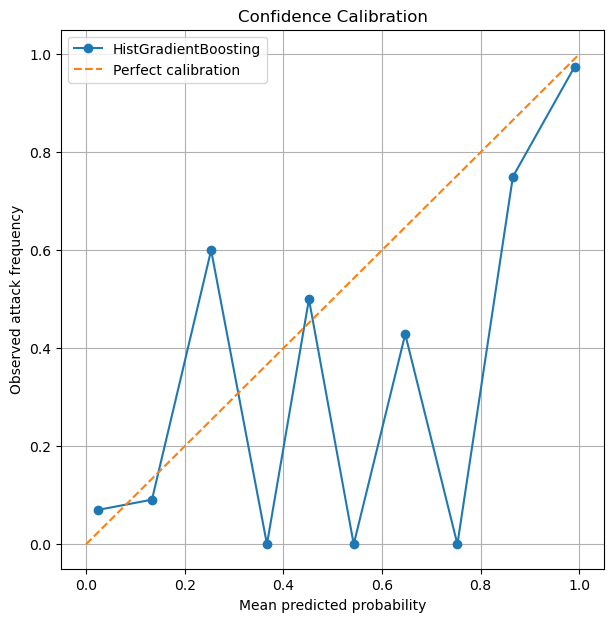

In [65]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_stream_val,
    hgb_val_proba,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7, 7))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="HistGradientBoosting"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed attack frequency")
plt.title("Confidence Calibration")
plt.legend()
plt.grid(True)
plt.show()

In [66]:
def get_alert_score(probability):
    """
    Convert model probability into an operational
    alert score and severity.

    Thresholds are prototype design choices and
    will be refined after calibration analysis.
    """

    if probability >= 0.90:
        severity = "CRITICAL"
    elif probability >= 0.80:
        severity = "HIGH"
    elif probability >= 0.60:
        severity = "MEDIUM"
    else:
        severity = "LOW"

    return {
        "confidence": round(float(probability), 4),
        "severity": severity
    }

In [67]:
for p in [0.42, 0.67, 0.81, 0.94, 0.99]:
    print(p, "→", get_alert_score(p))

0.42 → {'confidence': 0.42, 'severity': 'LOW'}
0.67 → {'confidence': 0.67, 'severity': 'MEDIUM'}
0.81 → {'confidence': 0.81, 'severity': 'HIGH'}
0.94 → {'confidence': 0.94, 'severity': 'CRITICAL'}
0.99 → {'confidence': 0.99, 'severity': 'CRITICAL'}


In [68]:
# ============================================================
# CALIBRATED HISTGRADIENTBOOSTING
# Calibration is learned using TRAINING DATA ONLY.
# ============================================================

from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Base model
calibration_base = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=200,
    max_leaf_nodes=15,
    l2_regularization=1.0,
    random_state=42
)

# Training weights
calibration_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_stream_train
)

# Cross-validated probability calibration
calibrated_hgb = CalibratedClassifierCV(
    estimator=calibration_base,
    method="sigmoid",
    cv=5
)

calibrated_hgb.fit(
    X_stream_train,
    y_stream_train,
    sample_weight=calibration_weights
)

print("Calibrated HGB model trained")

Calibrated HGB model trained


In [69]:
# ============================================================
# VALIDATION CALIBRATION
# ============================================================

calibrated_val_proba = calibrated_hgb.predict_proba(
    X_stream_val
)[:, 1]

calibrated_brier = brier_score_loss(
    y_stream_val,
    calibrated_val_proba
)

print(
    f"Original Brier score:   {brier:.4f}"
)

print(
    f"Calibrated Brier score: {calibrated_brier:.4f}"
)

Original Brier score:   0.0639
Calibrated Brier score: 0.0640


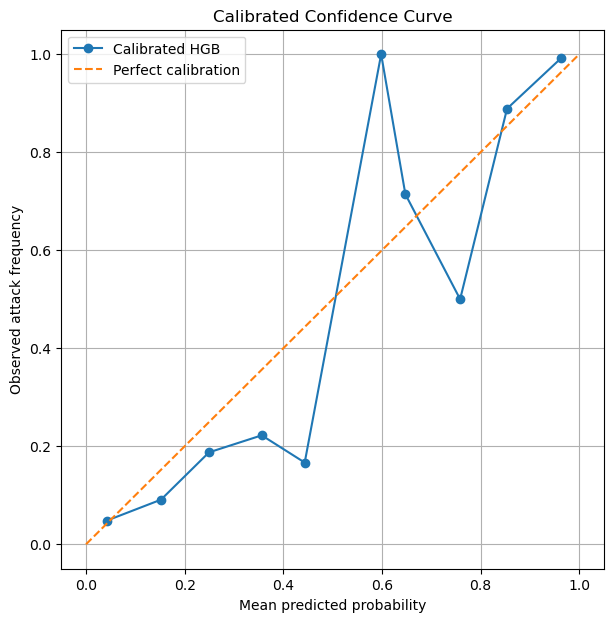

In [70]:
prob_true_cal, prob_pred_cal = calibration_curve(
    y_stream_val,
    calibrated_val_proba,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7, 7))

plt.plot(
    prob_pred_cal,
    prob_true_cal,
    marker="o",
    label="Calibrated HGB"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed attack frequency")
plt.title("Calibrated Confidence Curve")
plt.legend()
plt.grid(True)
plt.show()

In [71]:
import numpy as np
import pandas as pd
import scipy
import sklearn
import shap

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)
print("SHAP:", shap.__version__)
print("CODEZILLA ML STACK WORKS")

NumPy: 1.26.4
Pandas: 2.2.2
SciPy: 1.13.1
Scikit-learn: 1.5.1
SHAP: 0.46.0
CODEZILLA ML STACK WORKS


In [72]:
# ============================================================
# SHAP EXPLAINABILITY
# Use validation samples only.
# ============================================================

shap_sample_size = min(100, len(X_stream_val))

shap_sample = X_stream_val.sample(
    n=shap_sample_size,
    random_state=42
)

print("SHAP sample shape:", shap_sample.shape)

SHAP sample shape: (100, 62)


In [73]:
print("X_stream_train:", X_stream_train.shape)
print("X_stream_val:", X_stream_val.shape)
print("X_stream_test:", X_stream_test.shape)

print("HGB model:", type(temporal_hgb).__name__)

X_stream_train: (1361, 62)
X_stream_val: (292, 62)
X_stream_test: (292, 62)
HGB model: HistGradientBoostingClassifier


In [74]:
# ============================================================
# SHAP EXPLAINER
# ============================================================

explainer = shap.Explainer(
    temporal_hgb,
    shap_sample
)

print("SHAP explainer created")

SHAP explainer created


In [75]:
# ============================================================
# GENERATE SHAP VALUES
# Disable strict additivity check because of the
# sklearn HistGradientBoosting compatibility issue.
# ============================================================

shap_values = explainer(
    shap_sample,
    check_additivity=False
)

print("SHAP values generated")
print(
    "SHAP value shape:",
    shap_values.values.shape
)

SHAP values generated
SHAP value shape: (100, 62)


In [76]:
# ============================================================
# GLOBAL SHAP FEATURE IMPORTANCE
# ============================================================

shap_importance = pd.DataFrame({
    "Feature": shap_sample.columns,
    "Mean_Absolute_SHAP": np.abs(
        shap_values.values
    ).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top 20 features influencing the model:")
display(
    shap_importance.head(20)
)

Top 20 features influencing the model:


,Feature,Mean_Absolute_SHAP
0,total_packets,2.754662
1,total_bytes,0.872888
2,total_packets_rolling3,0.307487
3,max_packets_per_second_lag2,0.304187
4,max_bytes_per_second_lag3,0.267570
5,flow_count,0.267500
6,mean_bytes_per_second_rolling3,0.262160
7,total_packets_lag2,0.235485
8,mean_iat_rolling3,0.219352
9,mean_bytes_per_second,0.209665


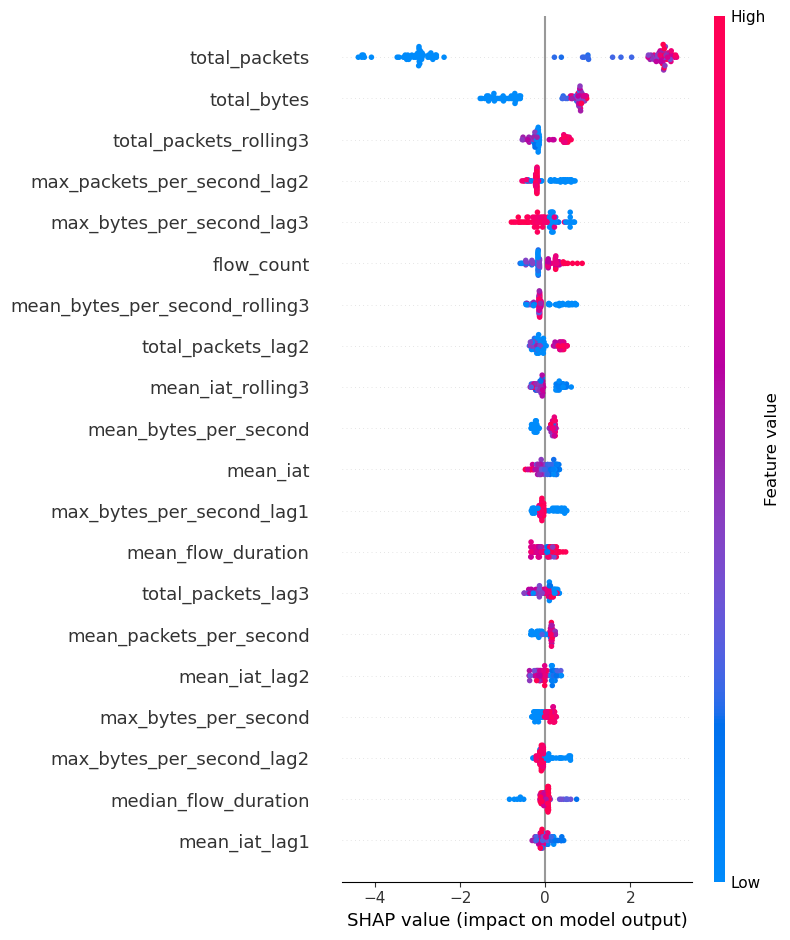

In [77]:
# ============================================================
# SHAP SUMMARY PLOT
# ============================================================

shap.summary_plot(
    shap_values,
    shap_sample,
    show=True
)

In [78]:
# ============================================================
# FIND A HIGH-SCORE ATTACK EXAMPLE
# ============================================================

sample_proba = temporal_hgb.predict_proba(
    shap_sample
)[:, 1]

attack_indices = np.where(
    sample_proba >= TEST_THRESHOLD
)[0]

print(
    "Samples with attack score >= threshold:",
    len(attack_indices)
)

if len(attack_indices) > 0:

    selected_idx = attack_indices[
        np.argmax(
            sample_proba[attack_indices]
        )
    ]

    print("Selected sample:", selected_idx)
    print(
        "Attack score:",
        round(
            float(sample_proba[selected_idx]),
            4
        )
    )

Samples with attack score >= threshold: 50
Selected sample: 59
Attack score: 0.9991


In [79]:
# ============================================================
# LOCAL SHAP EXPLANATION
# ============================================================

local_values = shap_values.values[
    selected_idx
]

local_explanation = pd.DataFrame({
    "Feature": shap_sample.columns,
    "Feature_Value": shap_sample.iloc[
        selected_idx
    ].values,
    "SHAP_Value": local_values
})

local_explanation["Abs_SHAP"] = (
    local_explanation["SHAP_Value"].abs()
)

local_explanation = (
    local_explanation
    .sort_values(
        "Abs_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top features influencing this attack prediction:")
display(
    local_explanation.head(15)
)

Top features influencing this attack prediction:


,Feature,Feature_Value,SHAP_Value,Abs_SHAP
0,total_packets,4.012460e+05,3.036666,3.036666
1,total_bytes,1.283987e+07,0.826236,0.826236
2,total_packets_lag2,4.336120e+05,0.440613,0.440613
3,total_packets_rolling3,3.557190e+05,0.434137,0.434137
4,flow_count,4.000000e+00,0.413711,0.413711
5,mean_iat,1.228083e+03,0.282483,0.282483
6,mean_bytes_per_second,2.681686e+04,0.209915,0.209915
7,flow_count_lag2,5.000000e+00,0.203251,0.203251
8,max_bytes_per_second,3.522591e+04,0.201161,0.201161
9,max_packets_per_second_lag2,1.136425e+03,-0.200030,0.200030


In [80]:
# ============================================================
# ATTACK-SUPPORTING EVIDENCE
# ============================================================

supporting_evidence = (
    local_explanation[
        local_explanation["SHAP_Value"] > 0
    ]
    .sort_values(
        "SHAP_Value",
        ascending=False
    )
    .head(10)
)

print("Evidence pushing prediction toward ATTACK:")
display(
    supporting_evidence[
        [
            "Feature",
            "Feature_Value",
            "SHAP_Value"
        ]
    ]
)

Evidence pushing prediction toward ATTACK:


,Feature,Feature_Value,SHAP_Value
0,total_packets,4.012460e+05,3.036666
1,total_bytes,1.283987e+07,0.826236
2,total_packets_lag2,4.336120e+05,0.440613
3,total_packets_rolling3,3.557190e+05,0.434137
4,flow_count,4.000000e+00,0.413711
5,mean_iat,1.228083e+03,0.282483
6,mean_bytes_per_second,2.681686e+04,0.209915
7,flow_count_lag2,5.000000e+00,0.203251
8,max_bytes_per_second,3.522591e+04,0.201161
10,mean_flow_duration,1.197045e+08,0.186283


In [81]:
# ============================================================
# COUNTER-EVIDENCE
# ============================================================

counter_evidence = (
    local_explanation[
        local_explanation["SHAP_Value"] < 0
    ]
    .sort_values(
        "SHAP_Value"
    )
    .head(10)
)

print("Evidence pushing prediction toward BENIGN:")
display(
    counter_evidence[
        [
            "Feature",
            "Feature_Value",
            "SHAP_Value"
        ]
    ]
)


Evidence pushing prediction toward BENIGN:


,Feature,Feature_Value,SHAP_Value
9,max_packets_per_second_lag2,1.136425e+03,-0.200030
13,mean_bytes_per_second_rolling3,2.050532e+04,-0.133969
14,max_bytes_per_second_lag2,3.636559e+04,-0.128324
17,max_packets_per_second_rolling3,1.079548e+03,-0.110343
19,mean_iat_rolling3,3.768593e+06,-0.098881
23,max_bytes_per_second_rolling3,3.454553e+04,-0.046071
25,flow_count_lag3,6.000000e+00,-0.044120
26,mean_bytes_per_second_lag1,2.022474e+04,-0.043736
27,max_bytes_per_second_lag1,3.542043e+04,-0.043267
28,total_packets_lag1,2.271120e+05,-0.031919


In [82]:
# ============================================================
# REUSABLE ML EVIDENCE GENERATOR
# ============================================================

def generate_ml_evidence(
    model,
    explainer,
    sample,
    threshold=0.80,
    top_k=5
):
    """
    Generate a structured ML prediction with
    supporting SHAP evidence.

    sample must be a one-row DataFrame using
    exactly the same 62 feature columns used
    during model training.
    """

    probability = float(
        model.predict_proba(sample)[0, 1]
    )

    prediction = int(
        probability >= threshold
    )

    shap_result = explainer(
        sample,
        check_additivity=False
    )

    shap_values_local = (
        shap_result.values[0]
    )

    evidence = pd.DataFrame({
        "feature": sample.columns,
        "feature_value": sample.iloc[0].values,
        "shap_value": shap_values_local
    })

    evidence["abs_shap"] = (
        evidence["shap_value"].abs()
    )

    if prediction == 1:

        supporting = (
            evidence[
                evidence["shap_value"] > 0
            ]
            .sort_values(
                "shap_value",
                ascending=False
            )
            .head(top_k)
        )

    else:

        supporting = (
            evidence[
                evidence["shap_value"] < 0
            ]
            .sort_values(
                "shap_value"
            )
            .head(top_k)
        )

    return {
        "prediction": (
            "ATTACK"
            if prediction == 1
            else "BENIGN"
        ),
        "model_score": round(
            probability,
            4
        ),
        "decision_threshold": threshold,
        "supporting_features": (
            supporting[
                [
                    "feature",
                    "feature_value",
                    "shap_value"
                ]
            ].to_dict(
                orient="records"
            )
        )
    }

In [83]:
# ============================================================
# TEST THE EVIDENCE GENERATOR
# ============================================================

example_alert = generate_ml_evidence(
    model=temporal_hgb,
    explainer=explainer,
    sample=shap_sample.iloc[[selected_idx]],
    threshold=TEST_THRESHOLD,
    top_k=5
)

print(example_alert)

{'prediction': 'ATTACK', 'model_score': 0.9991, 'decision_threshold': 0.8, 'supporting_features': [{'feature': 'total_packets', 'feature_value': 401246.0, 'shap_value': 3.0366660028224577}, {'feature': 'total_bytes', 'feature_value': 12839872.0, 'shap_value': 0.8262362006172771}, {'feature': 'total_packets_lag2', 'feature_value': 433612.0, 'shap_value': 0.44061337031424047}, {'feature': 'total_packets_rolling3', 'feature_value': 355719.0, 'shap_value': 0.4341372490220238}, {'feature': 'flow_count', 'feature_value': 4.0, 'shap_value': 0.4137110296403989}]}


In [84]:
# ============================================================
# VERIFY SHAP EXAMPLE AGAINST GROUND TRUTH
# ============================================================

selected_row = stream_model.loc[
    shap_sample.index[selected_idx]
]

print("Ground-truth window target:",
      int(selected_row["Window_Target"]))

print("Attack ratio:",
      float(selected_row["attack_ratio"]))

print("Time window:",
      selected_row["time_window"])

print("Model attack score:",
      round(float(sample_proba[selected_idx]), 4))

Ground-truth window target: 1
Attack ratio: 1.0
Time window: 2018-02-21 10:29:24
Model attack score: 0.9991


In [85]:
example_alert = generate_ml_evidence(
    model=temporal_hgb,
    explainer=explainer,
    sample=shap_sample.iloc[[selected_idx]],
    threshold=TEST_THRESHOLD,
    top_k=5
)

print(example_alert)

{'prediction': 'ATTACK', 'model_score': 0.9991, 'decision_threshold': 0.8, 'supporting_features': [{'feature': 'total_packets', 'feature_value': 401246.0, 'shap_value': 3.0366660028224577}, {'feature': 'total_bytes', 'feature_value': 12839872.0, 'shap_value': 0.8262362006172771}, {'feature': 'total_packets_lag2', 'feature_value': 433612.0, 'shap_value': 0.44061337031424047}, {'feature': 'total_packets_rolling3', 'feature_value': 355719.0, 'shap_value': 0.4341372490220238}, {'feature': 'flow_count', 'feature_value': 4.0, 'shap_value': 0.4137110296403989}]}


In [86]:
# ============================================================
# SAVE FINAL ML MODEL
# ============================================================

import joblib
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_PATH = MODEL_DIR / "dos_hgb.joblib"

joblib.dump(
    temporal_hgb,
    MODEL_PATH
)

print("✅ Model saved:")
print(MODEL_PATH)

✅ Model saved:
..\models\dos_hgb.joblib


In [87]:
# ============================================================
# SAVE FEATURE SCHEMA
# ============================================================

import json

feature_schema = {
    "feature_count": len(X_stream_train.columns),
    "features": X_stream_train.columns.tolist()
}

SCHEMA_PATH = (
    MODEL_DIR /
    "dos_feature_schema.json"
)

with open(
    SCHEMA_PATH,
    "w"
) as f:
    json.dump(
        feature_schema,
        f,
        indent=4
    )

print("✅ Feature schema saved")
print("Feature count:", feature_schema["feature_count"])

✅ Feature schema saved
Feature count: 62


In [88]:
# ============================================================
# SAVE MODEL METADATA
# ============================================================

metadata = {
    "model_name": "CODEZILLA-DOS-HGB",
    "model_type": "HistGradientBoostingClassifier",

    "task": "Temporal next-window DDoS detection",

    "window_size_seconds": 2,
    "prediction_horizon_seconds": 2,

    "feature_count": int(
        X_stream_train.shape[1]
    ),

    "decision_threshold": 0.80,

    "validation": {
        "precision": 0.9686,
        "recall": 0.9112,
        "f1": 0.9390,
        "fpr": 0.0407
    },

    "final_test": {
        "accuracy": 0.9075,
        "precision": 0.9625,
        "recall": 0.8800,
        "f1": 0.9194,
        "fpr": 0.0513
    },

    "confidence_calibration": {
        "method_tested": "sigmoid",
        "original_brier": 0.0639,
        "calibrated_brier": 0.0640,
        "selected": False
    }
}

METADATA_PATH = (
    MODEL_DIR /
    "dos_model_metadata.json"
)

with open(
    METADATA_PATH,
    "w"
) as f:
    json.dump(
        metadata,
        f,
        indent=4
    )

print("✅ Model metadata saved")

✅ Model metadata saved


In [89]:
# ============================================================
# EXPORT ONE KNOWN-GOOD MODEL INPUT FOR PACKAGING TEST
# ============================================================

PACKAGING_DIR = Path("../evaluation/packaging")
PACKAGING_DIR.mkdir(parents=True, exist_ok=True)

packaging_sample = X_stream_val.iloc[[0]].copy()

PACKAGING_SAMPLE_PATH = (
    PACKAGING_DIR / "sample_model_input.csv"
)

packaging_sample.to_csv(
    PACKAGING_SAMPLE_PATH,
    index=False
)

print("✅ Packaging sample exported")
print("Shape:", packaging_sample.shape)
print("Saved to:", PACKAGING_SAMPLE_PATH)

✅ Packaging sample exported
Shape: (1, 62)
Saved to: ..\evaluation\packaging\sample_model_input.csv


In [90]:
# ============================================================
# EXPORT HIGH-SCORE ATTACK EXAMPLE
# ============================================================

attack_mask = (
    temporal_hgb.predict_proba(X_stream_val)[:, 1]
    >= TEST_THRESHOLD
)

attack_rows = X_stream_val.loc[attack_mask]

if len(attack_rows) > 0:

    attack_sample = attack_rows.iloc[[0]].copy()

    ATTACK_SAMPLE_PATH = (
        PACKAGING_DIR /
        "sample_attack_input.csv"
    )

    attack_sample.to_csv(
        ATTACK_SAMPLE_PATH,
        index=False
    )

    print("✅ Attack packaging sample exported")
    print("Shape:", attack_sample.shape)

else:
    print("No validation attack found above threshold.")

✅ Attack packaging sample exported
Shape: (1, 62)


In [91]:
# ============================================================
# EXPORT VERIFIED ATTACK SAMPLE
# ============================================================

attack_sample = shap_sample.iloc[[selected_idx]].copy()

attack_sample_path = (
    PACKAGING_DIR /
    "verified_attack_input.csv"
)

attack_sample.to_csv(
    attack_sample_path,
    index=False
)

print("✅ Verified attack sample exported")
print("Shape:", attack_sample.shape)
print("Saved to:", attack_sample_path)

✅ Verified attack sample exported
Shape: (1, 62)
Saved to: ..\evaluation\packaging\verified_attack_input.csv


In [93]:
# ============================================================
# STEP 256 — BUILD & SAVE FINAL DDOS 62-FEATURE DATASET
# ============================================================

import json
from pathlib import Path
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# FIND PROJECT ROOT
# ------------------------------------------------------------

project_root = Path.cwd()

while not (project_root / "models").exists():
    if project_root.parent == project_root:
        raise RuntimeError("Could not find project root.")
    project_root = project_root.parent

print("Project root:", project_root)

# ------------------------------------------------------------
# LOAD EXACT MODEL SCHEMA
# ------------------------------------------------------------

schema_path = (
    project_root
    / "models"
    / "dos_feature_schema.json"
)

with open(
    schema_path,
    "r",
    encoding="utf-8"
) as f:
    dos_schema = json.load(f)

required_features = dos_schema["features"]

print(
    "Required DDoS features:",
    len(required_features)
)

# ------------------------------------------------------------
# USE EXISTING 2-SECOND DATASET
# ------------------------------------------------------------

if "stream_features" not in globals():
    raise RuntimeError(
        "stream_features is not available. "
        "Do not run this cell until the 2-second aggregation cell has run."
    )

ddos_features = stream_features.copy()

# ------------------------------------------------------------
# SORT TEMPORALLY
# ------------------------------------------------------------

ddos_features = (
    ddos_features
    .sort_values("time_window")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# EXACT BASE FEATURES
# ------------------------------------------------------------

base_features = [
    "flow_count",
    "total_packets",
    "total_bytes",
    "mean_flow_duration",
    "median_flow_duration",
    "mean_packets_per_second",
    "max_packets_per_second",
    "mean_bytes_per_second",
    "max_bytes_per_second",
    "mean_packet_size",
    "mean_iat",
    "mean_syn_count",
    "mean_ack_count",
    "mean_rst_count",
]

missing_base = [
    c for c in base_features
    if c not in ddos_features.columns
]

if missing_base:
    raise ValueError(
        "Missing base features: "
        + ", ".join(missing_base)
    )

# ------------------------------------------------------------
# TEMPORAL FEATURES
# ------------------------------------------------------------

temporal_features = [
    "flow_count",
    "total_packets",
    "total_bytes",
    "mean_packets_per_second",
    "max_packets_per_second",
    "mean_bytes_per_second",
    "max_bytes_per_second",
    "mean_packet_size",
    "mean_iat",
    "mean_syn_count",
    "mean_ack_count",
    "mean_rst_count",
]

# ------------------------------------------------------------
# LAG 1 / 2 / 3
# ------------------------------------------------------------

for col in temporal_features:

    ddos_features[f"{col}_lag1"] = (
        ddos_features[col].shift(1)
    )

    ddos_features[f"{col}_lag2"] = (
        ddos_features[col].shift(2)
    )

    ddos_features[f"{col}_lag3"] = (
        ddos_features[col].shift(3)
    )

# ------------------------------------------------------------
# PREVIOUS 3-WINDOW ROLLING MEAN
# ------------------------------------------------------------

for col in temporal_features:

    ddos_features[f"{col}_rolling3"] = (
        ddos_features[col]
        .shift(1)
        .rolling(
            3,
            min_periods=1
        )
        .mean()
    )

# ------------------------------------------------------------
# CLEAN NUMERIC VALUES
# ------------------------------------------------------------

ddos_features = (
    ddos_features
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

ddos_features[required_features] = (
    ddos_features[required_features]
    .fillna(0)
)

# ------------------------------------------------------------
# VERIFY EXACT MODEL INPUT
# ------------------------------------------------------------

present = [
    c for c in required_features
    if c in ddos_features.columns
]

missing = [
    c for c in required_features
    if c not in ddos_features.columns
]

print("\n================================")
print("DDOS FEATURE VERIFICATION")
print("================================")

print(
    "Required:",
    len(required_features)
)

print(
    "Present:",
    len(present)
)

print(
    "Missing:",
    len(missing)
)

if missing:
    print("\nMissing features:")
    for c in missing:
        print("-", c)

    raise RuntimeError(
        "DDoS feature schema is incomplete."
    )

print(
    "\n✅ ALL 62 DDoS FEATURES PRESENT"
)

print(
    "Final shape:",
    ddos_features.shape
)

print(
    "time_window:",
    "time_window" in ddos_features.columns
)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

output_dir = (
    project_root
    / "data"
    / "processed"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_path = (
    output_dir
    / "ddos_features.parquet"
)

ddos_features.to_parquet(
    output_path,
    index=False
)

print(
    "\n✅ DDOS FEATURES SAVED"
)

print(
    "Path:",
    output_path
)

Project root: e:\CODEZILLA-SIH26145
Required DDoS features: 62

DDOS FEATURE VERIFICATION
Required: 62
Present: 62
Missing: 0

✅ ALL 62 DDoS FEATURES PRESENT
Final shape: (1949, 65)
time_window: True

✅ DDOS FEATURES SAVED
Path: e:\CODEZILLA-SIH26145\data\processed\ddos_features.parquet


In [94]:
# ============================================================
# STEP 260 — DDOS PRODUCTION MODEL TEST
# ============================================================

import json
import joblib
import pandas as pd

# ------------------------------------------------------------
# Load exact schema
# ------------------------------------------------------------

schema_path = (
    project_root
    / "models"
    / "dos_feature_schema.json"
)

with open(
    schema_path,
    "r",
    encoding="utf-8"
) as f:
    dos_schema = json.load(f)

required_features = dos_schema["features"]

# ------------------------------------------------------------
# Load trained model
# ------------------------------------------------------------

model_path = (
    project_root
    / "models"
    / "dos_hgb.joblib"
)

dos_model = joblib.load(
    model_path
)

# ------------------------------------------------------------
# Prepare EXACT 62-feature input
# ------------------------------------------------------------

X_ddos = ddos_features[
    required_features
].copy()

# ------------------------------------------------------------
# Predict
# ------------------------------------------------------------

ddos_probability = (
    dos_model
    .predict_proba(X_ddos)[:, 1]
)

DDOS_THRESHOLD = 0.80

ddos_prediction = (
    ddos_probability >= DDOS_THRESHOLD
).astype(int)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("================================")
print("DDOS PRODUCTION MODEL TEST")
print("================================")

print(
    "Rows:",
    len(X_ddos)
)

print(
    "Features:",
    X_ddos.shape[1]
)

print(
    "Threshold:",
    DDOS_THRESHOLD
)

print(
    "Predicted attacks:",
    int(ddos_prediction.sum())
)

print(
    "Maximum model score:",
    round(
        float(ddos_probability.max()),
        4
    )
)

print(
    "Mean model score:",
    round(
        float(ddos_probability.mean()),
        4
    )
)

# ------------------------------------------------------------
# Create inference table WITH context
# ------------------------------------------------------------

ddos_results = pd.DataFrame({
    "time_window": ddos_features[
        "time_window"
    ],

    "prediction": (
        ddos_prediction
        .astype(int)
    ),

    "model_score": ddos_probability,

    "threat_class": "DDoS",

    "severity": [
        (
            "HIGH"
            if score >= 0.95
            else "MEDIUM"
        )
        for score in ddos_probability
    ],
})

print(
    "\n✅ DDoS inference completed"
)

display(
    ddos_results
    .sort_values(
        "model_score",
        ascending=False
    )
    .head(20)
)

DDOS PRODUCTION MODEL TEST
Rows: 1949
Features: 62
Threshold: 0.8
Predicted attacks: 1207
Maximum model score: 0.9998
Mean model score: 0.6352

✅ DDoS inference completed


,time_window,prediction,model_score,threat_class,severity
607,2018-02-21 02:29:48,1,0.999771,DDoS,HIGH
329,2018-02-21 02:20:32,1,0.999771,DDoS,HIGH
343,2018-02-21 02:21:00,1,0.999771,DDoS,HIGH
342,2018-02-21 02:20:58,1,0.999771,DDoS,HIGH
341,2018-02-21 02:20:56,1,0.999771,DDoS,HIGH
339,2018-02-21 02:20:52,1,0.999771,DDoS,HIGH
337,2018-02-21 02:20:48,1,0.999771,DDoS,HIGH
336,2018-02-21 02:20:46,1,0.999771,DDoS,HIGH
335,2018-02-21 02:20:44,1,0.999771,DDoS,HIGH
334,2018-02-21 02:20:42,1,0.999771,DDoS,HIGH


In [95]:
# ============================================================
# STEP 261 — SAVE DDOS INFERENCE RESULTS
# ============================================================

output_dir = (
    project_root
    / "data"
    / "processed"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_path = (
    output_dir
    / "ddos_inference.parquet"
)

ddos_results.to_parquet(
    output_path,
    index=False
)

print(
    "✅ DDoS inference artifact saved"
)

print(
    "Path:",
    output_path
)

✅ DDoS inference artifact saved
Path: e:\CODEZILLA-SIH26145\data\processed\ddos_inference.parquet


In [96]:
# ============================================================
# STEP 262 — DDOS ARTIFACT SANITY CHECK
# ============================================================

print("DDoS artifact shape:", ddos_features.shape)

print("\nTime range:")
print("First:", ddos_features["time_window"].min())
print("Last :", ddos_features["time_window"].max())

print("\nWindow target distribution:")
if "Window_Target" in ddos_features.columns:
    print(ddos_features["Window_Target"].value_counts())
else:
    print("Window_Target not present")

print("\nModel score distribution:")
print(ddos_results["model_score"].describe())

print("\nPredicted attack distribution:")
print(ddos_results["prediction"].value_counts())

print("\nTop 10 predictions:")
display(
    ddos_results
    .sort_values(
        "model_score",
        ascending=False
    )
    .head(10)
)

DDoS artifact shape: (1949, 65)

Time range:
First: 2018-02-21 01:55:46
Last : 2018-02-21 10:43:20

Window target distribution:
Window_Target
1    1240
0     709
Name: count, dtype: int64

Model score distribution:
count    1949.000000
mean        0.635150
std         0.465433
min         0.000335
25%         0.007250
50%         0.994811
75%         0.999685
max         0.999771
Name: model_score, dtype: float64

Predicted attack distribution:
prediction
1    1207
0     742
Name: count, dtype: int64

Top 10 predictions:


,time_window,prediction,model_score,threat_class,severity
607,2018-02-21 02:29:48,1,0.999771,DDoS,HIGH
329,2018-02-21 02:20:32,1,0.999771,DDoS,HIGH
343,2018-02-21 02:21:00,1,0.999771,DDoS,HIGH
342,2018-02-21 02:20:58,1,0.999771,DDoS,HIGH
341,2018-02-21 02:20:56,1,0.999771,DDoS,HIGH
339,2018-02-21 02:20:52,1,0.999771,DDoS,HIGH
337,2018-02-21 02:20:48,1,0.999771,DDoS,HIGH
336,2018-02-21 02:20:46,1,0.999771,DDoS,HIGH
335,2018-02-21 02:20:44,1,0.999771,DDoS,HIGH
334,2018-02-21 02:20:42,1,0.999771,DDoS,HIGH
